<div style="text-align: center;">

# Assignment 3

## Hydrolysis of Ethylene Oxide to Ethylene Glycol in a Plug Flow Tubular Reactor

### Manda Sasikala, Noah Herrscher, Benjamin Heuschmid

</div>



## 1. Introduction

Plug flow tubular reactors (PFTRs) are widely used in the chemical industry for continuous production processes because they provide efficient conversion and allow good control over reaction conditions. Compared to batch reactors, PFTRs operate under steady-state conditions and are particularly suitable for large-scale applications where heat transfer and residence time strongly influence reactor performance. For exothermic reactions, temperature control becomes especially important, since heat released during the reaction can significantly affect reaction rates and process stability [1].

In this work, the hydrolysis of ethylene oxide (EO) with water to produce ethylene glycol (EG) is investigated as an example of an exothermic reaction system. Ethylene glycol is an industrially important chemical used in applications such as antifreeze products and polyester manufacturing. Since the reaction releases heat, reactor operation depends not only on reaction kinetics but also on thermal effects and operating conditions [2].

The aim of this study is to analyze the behavior of the reaction system in a plug flow tubular reactor by investigating the influence of relevant process parameters. Parameters such as heat transfer coefficients, inlet temperature, reactant concentration and flow-related conditions are evaluated to better understand their impact on reactor temperature and reaction behavior. 

## 2.Motivation
The hydrolysis of ethylene oxide to ethylene glycol is an industrially important reaction due to the widespread use of ethylene glycol in various applications. Understanding the interaction between reaction kinetics, heat generation and reactor operation is essential for the safe and efficient design of chemical reactors. This study aims to develop a mathematical model for a plug flow tubular reactor (PFTR) and investigate how operating parameters such as cooling intensity, inlet temperature, inlet concentration, and fluid velocity influence the reactor performance. The analysis provides valuable insights into reactor behavior and helps identify conditions that maximize conversion while maintaining safe operating temperatures [1,2].


## 3. Mathematical Model
The hydrolysis of ethylene oxide (EO) to ethylene glycol (EG) was modeled using a plug flow tubular reactor (PFTR). The reactor was transformed into an initial value problem using the residence time concept. Constant fluid velocity, liquid-phase operation and first-order reaction kinetics with respect to EO were assumed.

The residence time was calculated from the reactor length and fluid velocity according to:
$$
\tau = \frac{L}{u}
$$

The investigated reaction is:
$$
EO + H_2O \rightarrow EG
$$
For the PFTR model, axial mixing and radial concentration gradients were neglected. Therefore, the reactor was assumed to behave ideally, and concentration and temperature were considered to vary only along the reactor length without back-mixing.

The reactor operates under steady-state plug flow conditions.

The reaction mixture remains in the liquid phase throughout the reactor.

Fluid velocity is assumed constant along the reactor length.

Axial mixing and radial gradients are neglected.

Heat transfer occurs only through the reactor wall.

The reaction follows first-order kinetics with respect to ethylene oxide.

## 4. Governing Equations

The reactor system was described using mass and energy balances coupled with temperature-dependent reaction kinetics.

### Arrhenius kinetics


$$
k(T)=5.01 \cdot 10 ^ {6} \cdot \exp \left(-\frac{72500}{RT}\right)
$$


### Reaction rate equation


$$
r = k(T)c_{EO}
$$


### Component balances

Consumption of ethylene oxide:


$$
\frac{dc_{EO}}{dx} = -r / u
$$


Formation of ethylene glycol:


$$
\frac{dc_{EG}}{dx} = r / u
$$


### Energy balance

$$
\frac{dT}{dx}
=
\frac{-\Delta H_R r}{\rho c_p u}
-
\frac{h_W A_R (T-T_c)}
{\rho c_p V_R u}
$$


## 5. Python Implementation and Sensitivity Analysis

The developed PFTR model was numerically implemented to simulate concentration and temperature changes along the reactor length. The implementation includes the reaction kinetics, material balances, and energy balance while accounting for heat transfer through the reactor wall.

To investigate the influence of operating conditions on reactor performance, a sensitivity analysis was carried out. Key parameters including wall heat-transfer coefficient, inlet reactant concentration, and inlet temperature were varied systematically to evaluate their effect on reactor temperature and concentration profiles. The obtained results were visualized to compare reactor behavior under different operating conditions.


In [77]:
import numpy as np
from scipy.interpolate import interp1d
import scipy.integrate as integ  # important for initial value problem
import matplotlib.pyplot as plt  # figures
from scipy.optimize import root
from scipy.integrate import solve_ivp

### 5.1 Input Parameters and Initial Conditions
The kinetic, thermodynamic, and geometric parameters required for the PFTR model are defined. In addition, the inlet conditions and reactor operating conditions are specified. These values are used as reference points throughout all simulations and sensitivity analyses.

In [78]:
# Data Parameters

E_A = 72500      # activation energy J/mol
k_0 = 5.01E06       # pre-exponential factor 1/s
R = 8.314        # gas constant J/(mol K)
H_R = -92200     # reaction enthalpy J/mol

d_R = 0.03       # tube diameter m
L_R = 300        # reactor length m
h_wall = 500     # wall heat transfer coefficient W/(m^2 K)  [= 0.5 kJ/(s m^2 K)]
u_ref = 1.0          # fluid velocity m/s

rho = 1000       # density of reaction mixture kg/m^3
c_p = 4190       # heat capacity J/(kg K)

# Initial conditions (= inlet conditions for PFTR)
c_10 = 2270      # inlet concentration EO mol/m^3
c_20 = 0         # inlet concentration EG mol/m^3
T_0 = 423        # inlet temperature K
T_wall = 423     # wall temperature K (fixed, independent of position)

# Precalculations
C = c_p * rho              # volumetric heat capacity J/(m^3 K)
a_wall = 4 / d_R           # specific wall area m^2_wall/m^3_reactor  (= pi*d / (pi*d^2/4))
A_ref = np.pi * d_R ** 2 / 4

### 5.2 Reaction Kinetics and Governing Equations
The reaction kinetics and governing equations were implemented. The Arrhenius equation was used to calculate the reaction rate constant, while material and energy balances were formulated as ordinary differential equations along the reactor length. These equations describe the consumption of ethylene oxide, the formation of ethylene glycol and the temperature evolution inside the reactor.

In [79]:
def kinetics(T, c_1):
    """Arrhenius reaction rate, first order in c_1."""
    k_1 = k_0 * np.exp(-E_A / (R * T))   # rate constant 1/s
    r = k_1 * c_1                          # reaction rate mol/(m^3 s)
    return r

def PFTR_constant_h(L, f):
    """
    Spatial derivatives for the PFTR material and energy balances.

    f[0] = c_1  (EO concentration, mol/m^3)
    f[1] = c_2  (EG concentration, mol/m^3)
    f[2] = T    (temperature, K)

    Space-time transformation:  d/dL = (1/u_ref) * d/dt
    Each right-hand side is the bSTR time-derivative divided by u_ref.
    """
    c_1 = f[0]
    c_2 = f[1]
    T   = f[2]

    r = kinetics(T, c_1)

    # Component balances (material balance per unit reactor length)
    dc_1dL = -r / u_ref
    dc_2dL =  r / u_ref

    # Energy balance per unit reactor length
    # Reaction term:    -H_R * r / C              [K/s] / [m/s] = K/m
    # Heat-transfer:    h_wall * a_wall * (T-T_wall) / C  [K/m]
    dTdL = (-H_R * r / C - h_wall * a_wall * (T - T_wall) / C) / u_ref

    dfdL = np.empty_like(f)
    dfdL[0] = dc_1dL
    dfdL[1] = dc_2dL
    dfdL[2] = dTdL
    return dfdL

### 5.3 Numerical Solution and Base Case Simulation
The system of differential equations is solved using the BDF solver available in SciPy. The resulting concentration and temperature profiles along the reactor length are used as the reference case for further analysis.

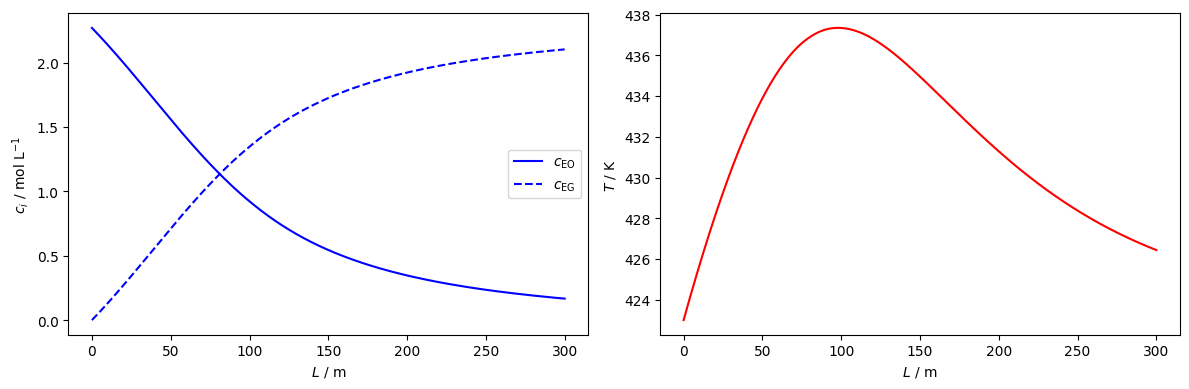

In [80]:
# Initial (inlet) conditions
f_init = np.array([c_10, c_20, T_0])

# Solve
Lspan = np.array([0, L_R])
leval = np.linspace(0, Lspan[1], 2001)
sol = integ.solve_ivp(PFTR_constant_h, Lspan, f_init, method='BDF', t_eval=leval)

# POSTPROCESSING & PLOTTING

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.set(xlabel='$L$ / m', ylabel='$c_i$ / mol L$^{-1}$')
ax1.plot(sol.t, sol.y[0, :] / 1000, 'b-',  label='$c_{\\mathrm{EO}}$')
ax1.plot(sol.t, sol.y[1, :] / 1000, 'b--', label='$c_{\\mathrm{EG}}$')
ax1.legend()

ax2.set(xlabel='$L$ / m', ylabel='$T$ / K')
ax2.plot(sol.t, sol.y[2, :], 'r-')

fig.tight_layout()
plt.show()

The base-case simulation shows the consumption of ethylene oxide (EO) and the formation of ethylene glycol (EG) along the reactor length. As expected, the EO concentration decreases continuously while the EG concentration increases due to the reaction. The temperature initially rises because of the exothermic reaction and reaches a maximum at around 100m of the reactor. Further downstream, heat transfer to the reactor wall causes the temperature to decrease gradually.

### 5.4 Sensitivity Analysis Setup

A generalized reactor model is defined to evaluate the influence of different operating parameters on reactor performance. The wall heat-transfer coefficient, inlet concentration, and inlet temperature are varied while keeping the remaining parameters constant

In [81]:
#%%

def PFTR(L, f, h, T_in):
    c_1, c_2, T = f[0], f[1], f[2]
    r = kinetics(T, c_1)
    dc_1dL = -r / u_ref
    dc_2dL =  r / u_ref
    dTdL = (-H_R * r / C - h * a_wall * (T - T_wall) / C) / u_ref
    dfdL = np.empty_like(f)
    dfdL[0] = dc_1dL
    dfdL[1] = dc_2dL
    dfdL[2] = dTdL
    return dfdL

Lspan = np.array([0, L_R])
leval = np.linspace(0, Lspan[1], 2001)


### 5.4.1 Effect of Wall Heat Transfer Coefficient

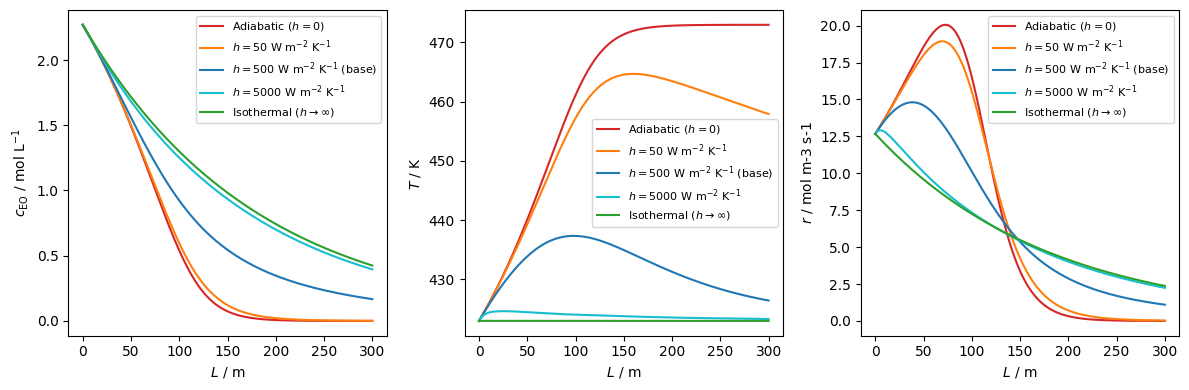

In [82]:
# Sensitivity 1: Cooling Power (h_wall)

h_cases = {
    'Adiabatic ($h = 0$)':                   0,
    '$h = 50$ W m$^{-2}$ K$^{-1}$':         50,
    '$h = 500$ W m$^{-2}$ K$^{-1}$ (base)': 500,
    '$h = 5000$ W m$^{-2}$ K$^{-1}$':       5000,
    'Isothermal ($h \\to \\infty$)':         1e6,
}

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
ax1.set(xlabel='$L$ / m', ylabel='$c_{\\mathrm{EO}}$ / mol L$^{-1}$')
ax2.set(xlabel='$L$ / m', ylabel='$T$ / K')
ax3.set(xlabel='$L$ / m', ylabel='$r$ / mol m-3 s-1')
colors = ['tab:red', 'tab:orange', 'tab:blue', 'tab:cyan', 'tab:green']

for (label, h), color in zip(h_cases.items(), colors):
    f_init = np.array([c_10, c_20, T_0])
    sol = integ.solve_ivp(PFTR, Lspan, f_init, args=(h, T_0), method='BDF', t_eval=leval)
    ax1.plot(sol.t, sol.y[0, :] / 1000, color=color, label=label)
    ax2.plot(sol.t, sol.y[2, :],         color=color, label=label)
    ax3.plot(sol.t, kinetics(sol.y[2, :], sol.y[0, :]),  color=color, label=label)

ax1.legend(fontsize=8)
ax2.legend(fontsize=8)
ax3.legend(fontsize=8)
fig.tight_layout()
plt.show()



The influence of the wall heat-transfer coefficient was investigated by varying the cooling intensity from adiabatic operation to nearly isothermal conditions. Lower heat-transfer coefficients result in higher reactor temperatures because less heat is removed from the system. Consequently, reaction rates increase and higher conversions are achieved locally due to the combination of higher temperature and concentration of EO. This can be seen at the point of inflection of the concentration profiles of EO and the maxima of the reaction rates and thus having the highest consumption of EO. Increasing the heat-transfer coefficient suppresses the temperature rise and leads to lower reaction rate maxima. Under nearly isothermal conditions, the reactor temperature remains at the wall temperature throughout the reactor and no amplification of the reaction rate takes place.

### 5.4.2 Effect of Inlet EO Concentration

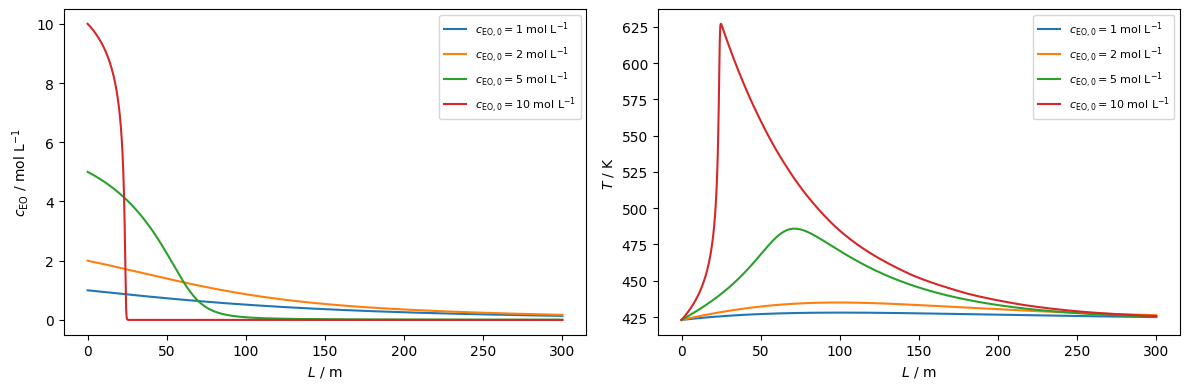

In [83]:
# Sensitivity 2: Inlet Concentration (base: h=500, T_0=423 K)

c_cases = {
    '$c_{\\mathrm{EO,0}} = 1$ mol L$^{-1}$':  1000,
    '$c_{\\mathrm{EO,0}} = 2$ mol L$^{-1}$':  2000,
    '$c_{\\mathrm{EO,0}} = 5$ mol L$^{-1}$':  5000,
    '$c_{\\mathrm{EO,0}} = 10$ mol L$^{-1}$': 10000,
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.set(xlabel='$L$ / m', ylabel='$c_{\\mathrm{EO}}$ / mol L$^{-1}$')
ax2.set(xlabel='$L$ / m', ylabel='$T$ / K')
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

for (label, c_in), color in zip(c_cases.items(), colors):
    f_init = np.array([c_in, c_20, T_0])
    sol = integ.solve_ivp(PFTR, Lspan, f_init, args=(h_wall, T_0), method='BDF', t_eval=leval)
    ax1.plot(sol.t, sol.y[0, :] / 1000, color=color, label=label)
    ax2.plot(sol.t, sol.y[2, :],         color=color, label=label)

ax1.legend(fontsize=8)
ax2.legend(fontsize=8)
fig.tight_layout()
plt.show()

The inlet concentration of ethylene oxide strongly influences both conversion and temperature profiles. Higher inlet concentrations increase the reaction rate and generate more reaction heat. As a result, larger temperature peaks are observed and the reactant is consumed more rapidly. At low inlet concentrations, the temperature increase remains moderate and conversion proceeds more gradually along the reactor length due to the cooling being still effective.

### 5.4.3 Effect of Inlet Temperature

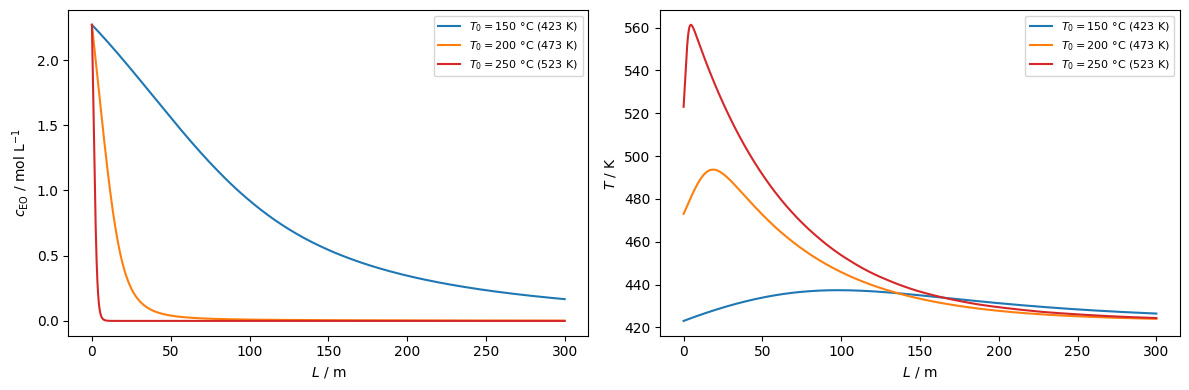

In [84]:
# Sensitivity 3: Inlet Temperature (base: h=500, c_10=2270 mol/m^3)
# 150°C = 423 K, 200°C = 473 K, 250°C = 523 K

T_cases = {
    '$T_0 = 150$ °C (423 K)': 423,
    '$T_0 = 200$ °C (473 K)': 473,
    '$T_0 = 250$ °C (523 K)': 523,
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.set(xlabel='$L$ / m', ylabel='$c_{\\mathrm{EO}}$ / mol L$^{-1}$')
ax2.set(xlabel='$L$ / m', ylabel='$T$ / K')
colors = ['tab:blue', 'tab:orange', 'tab:red']

for (label, T_in), color in zip(T_cases.items(), colors):
    f_init = np.array([c_10, c_20, T_in])
    sol = integ.solve_ivp(PFTR, Lspan, f_init, args=(h_wall, T_in), method='BDF', t_eval=leval)
    ax1.plot(sol.t, sol.y[0, :] / 1000, color=color, label=label)
    ax2.plot(sol.t, sol.y[2, :],         color=color, label=label)

ax1.legend(fontsize=8)
ax2.legend(fontsize=8)
fig.tight_layout()
plt.show()

The effect of inlet temperature was studied by comparing reactor operation at 150°C, 200°C and 250°C. Increasing the inlet temperature significantly accelerates the reaction because of the Arrhenius dependence of the reaction rate constant. Consequently, ethylene oxide is consumed much faster and higher temperature peaks are observed. Lower inlet temperatures lead to slower reaction rates and lower overall conversion within the reactor.


## 6 Adapting the thermodynamics
The given heat capacity $c_p = 4.19$ kJ mol $^{-1}$ K $^{-1}$ and density $\rho = 1000$ kg m $^{-3}$ describe the properties of water. But in reality the mixture behaves thermodynamically differently depending on the local composition and temperature. This can lead to large deviations and thus potentially large errors. In literature the hydrogenation of EO is often described as a liquid-phase reaction taking place at higher pressures [cite]. This allows the use of correlations for saturated liquids. The approximation error increases near the critical temperatures, which limits the range of reliable temperatures.
If the temperature range given by the correlations is exceeded during calculation, the value for the highest possible temperature is taken as constant. This negates calculation failures.

### 6.1 Calculation of the heat capacity
The heat capacities of the pure components water and EG are calculated using the VDI heat atlas correlation for saturated liquids (Equation 1 and Table 1) [3]. 

$$
 c_{p,i}(T) = R_i \cdot \left[\frac{A_i}{1 - \frac{T}{T_{C,i}}} + B_i + C_i\left(1 - \frac{T}{T_{C,i}}\right) + D_i\left(1 - \frac{T}{T_{C,i}}\right)^2 + E_i\left(1 - \frac{T}{T_{C,i}}\right)^3 + F_i\left(1 - \frac{T}{T_{C,i}}\right)^4\right] \times 1000 \tag{1}
$$

This correlation uses the specific gas constant $R_i = \frac{R}{M_i}$.

Table 1: Parameters for the heat capacities of liquids [3]
| | $T_{C}$ (K) | A | B | C | D | E | F | Temperature range (°C) |
| --------------- | --------------- | --------------- | ------------------------- | ------------------------- |  ------------------------- | ------------------------- | ------------------------- | ------------------------- | 
| Water | 647.10 | 0.2399 | 12.8647 | -33.6392 | 104.7686 | -155.4709 | 92.3726 | 0 - 250|
| EG | 724.05 | 0 | 33.1585 | -25.9580 | 0 | 0 | 0 | 0 - 200 |
| EO | 469.15 | - | - | - | - | - | - | - |

For EO there are no parameters available for the correlation in the relevant temperature range. Therefore interpolated data are used (Table 2) [3].

Table 2: Measured heat capacities for EO [1]
| $T$ (°C) | -40 | -20 | 0 | 20 | 40 | 60 | 80 | 100 |
|---|---|---|---|---|---|---|---|---|
| $c_{p,\mathrm{EO}}$ (J kg $^{-1}$ K $^{-1}$ ) | 1880 | 1910 | 1950 | 2000 | 2060 | 2150 | 2270 | 2400 |

For the mixture heat capacity, an ideal mixture and weight fractions are used because the property is mass-specific (Equation 2) [3]. 

$$ c_{p,mix} = \sum_i w_i c_{p,i}  \tag{2}$$

Because molar fractions are easier to calculate, mass fractions are obtained using Equation 3 [3].

$$
w_i = \frac{x_i \, M_i}{\sum_j x_j \, M_j} \tag{3}
$$

### 6.2 Calculation of the density
The densities of the pure components water, EG and EO are calculated using the VDI heat atlas correlation for saturated liquids (Equation 4 and Table 3) [3]. 

$$
\rho_i(T) = \rho_{i,c} + A_i \left(1 - \frac{T}{T_{C,i}}\right)^{0.35} + B_i \left(1 - \frac{T}{T_{C,i}}\right)^{2/3} + C_i \left(1 - \frac{T}{T_{C,i}}\right) + D_i \left(1 - \frac{T}{T_{C,i}}\right)^{4/3} \tag{4}
$$

Table 3: Parameters for the density of liquids [3]
| | $\rho_{i,c}$ (kg/m³) | A | B | C | D | Temperature range (°C) |
|---|---|---|---|---|---|--|
| Water | 322 | 1094.0233 | -1813.2295 | 3863.9557 | -2479.8130 | 0 - 250|
| EG | 325 | 1305.5931 | -1374.2561 | 1691.0501 | -665.0358 | 0 - 250 |
| EO | 314 | 757.9994 | -286.5638 | 583.1649 | -177.0206 | -50 - 150 |

For mixing behavior, an ideal mixture is assumed. The mixture density is calculated using Equation 5. The mass fractions are computed from Equation 3 [3].

$$
\rho_{mix} = \frac{1}{\sum_i \frac{w_i}{\rho_i}} \tag{5}
$$

### 6.3 Calculation of the heat conductivity
The heat conductivities of the pure components water and EG are calculated using the VDI heat atlas correlation for saturated liquids (Equation 6 and Table 4) [3].
$$
\lambda_i(T) = A_i + \frac{B_i}{10^2}T + \frac{C_i}{10^4}T^2 + \frac{D_i}{10^7}T^3 + \frac{E_i}{10^{10}}T^4 \tag{6}
$$

Table 4: Parameters for the heat conductivity of liquids [3]
| | $A$ | $B$ | $C$ | $D$ | $E$ | Temperature range (°C) |
|---|---|---|---|---|---|---|
| Water | -2.4149 | 2.45165 | -0.73121 | 0.99492 | -0.53730 | 0 - 200 |
| EG | 0.1125 | 0.06626 | -0.00088 | -0.02300 | 0.01597 | 0 - 150 |
| EO | - | - | - | - | - | - |

For EO there are no parameters available for the correlation in the relevant temperature range. Therefore interpolated data are used (Table 5) [1,3].

Table 5: Measured thermal conductivity for EO [1]
| $T$ (°C) | 20 | 30 | 40 | 50 | 60 | 70 | 80 | 100 |
|---|---|---|---|---|---|---|---|---|
| $\lambda_{EO}$ (W m$^{-1}$ K$^{-1}$) | 0.153 | 0.150 | 0.147 | 0.143 | 0.140 | 0.137 | 0.134 | 0.125 |

For mixing behavior, an ideal mixture is assumed. The heat conductivity of the mixture is calculated using Equation 7 [3]. 

$$\lambda_{mix} = \sum_i x_i \lambda_i \tag{7}$$

### 6.4 Calculation of the viscosity
The viscosities of the pure components water and EG are calculated using the VDI heat atlas correlation for saturated liquids (Equation 8 and Table 6) [3].

$$ \eta_i(T) = F_i \exp\left[A_i\left(\frac{C-T}{T-D}\right)^{1/3} + B_i\left(\frac{C-T}{T-D}\right)^{4/3}\right]  \tag{8}$$

According to the VDI atlas, modifications were made to the correlation to ensure correct signs [3].

Table 6: Parameters for the viscosity of liquids [3]
| | $A$ | $B$ | $C$ | $D$ | $F$ | Temperature range (°C) |
|---|---|---|---|---|---|---|
| Water | 0.45047 | 1.39753 | 613.181 | 63.697 | 0.00006896 | 0 - 200 |
| EG | -0.44356 | 1.31885 | 895.784 | 79.362 | 0.00020318 | 0 - 150 |
| EO | - | - | - | - | - | - |

For EO there are no parameters available for the correlation in the relevant temperature range. Therefore interpolated data are used (Table 7) [1,3].

Table 7: Measured viscosity for EO [1]
| $T$ (°C) | 20 | 30 | 40 | 50 | 60 | 70 | 80 | 100 |
|---|---|---|---|---|---|---|---|---|
| $\eta_{EO}$ (Pa·s) | 0.00025 | 0.00023 | 0.00021 | 0.00019 | 0.00018 | 0.00016 | 0.00015 | 0.00014 |

For mixing behavior, an ideal mixture is assumed. The viscosity of the mixture is calculated using Equation 9 [3]. 

$$ \eta_{mix} = \sum_i x_i \eta_i \tag{9} $$

### 6.5 Calculation of the molar mass
The molar mass of the mixture is calculated using Equation 10 [3].
$$ M_{mix} = \sum_i x_iM_i \tag{10}$$

In [85]:
M_WA = 18.01 # Molar mass of water in g mol-1
M_EG = 62.07 # Molar mass of ethylene glycol in g mol-1
M_EO = 44.05 # Molar mass of ethylene oxide in g mol-1

R_WA = 8.314 / M_WA # Specific heat capacity of water in 
R_EG = 8.314 / M_EG # Specific heat capacity of ethylene glycol in 
R_EO = 8.314 / M_EO # Specific heat capacity of ethylene oxide in 

T_C_EG = 724.05 # Critical temperature of ethylene glycol in K
T_C_WA = 647.10 # Critical temperature of water in K 
T_C_EO = 469.15 # Critical temperature of ethylene oxide in K 

c_p_EG_params = np.array([0, 33.1585, -25.9580, 0, 0, 0]) # Parameters for the specific heat capacity of ethylene glycol correlation
c_p_WA_params = np.array([0.2399, 12.8647, -33.6392, 104.7686, -155.4709, 92.3726]) # Parameters for the specific heat capacity of water correlation



# Heat capacity of ethylene glycol dependent on temperature in J kg-1 K-1
def c_p_EG(T):
    if type(T) is np.ndarray:
        T_inp = T.copy()
    else:
        T_inp = T


    if type(T) is np.ndarray:
        for i, T_val in enumerate(T_inp):
            if T_val > (273.15 + 200):
                T_inp[i] = 200 + 273.15

    else:
        if T > (273.15 + 200):
            T_inp = (273.15 + 200) 

    return R_EG * (c_p_EG_params[0] / (1- (T_inp / T_C_EG)) + c_p_EG_params[1] + c_p_EG_params[2] * (1 - (T_inp / T_C_EG)) + c_p_EG_params[3] * (1 - (T_inp / T_C_EG))**2 + c_p_EG_params[4] * (1 - (T_inp / T_C_EG))**3 + c_p_EG_params[5] * (1 - (T_inp / T_C_EG))**4) * 1000

# Heat capacity of water dependent on temperature in  J kg-1 K-1
def c_p_WA(T):
    if type(T) is np.ndarray:
        T_inp = T.copy()
    else:
        T_inp = T


    if type(T) is np.ndarray:
        for i, T_val in enumerate(T_inp):
            if T_val > (273.15 + 250):
                T_inp[i] = 250 + 273.15

    else:
        if T > (273.15 + 250):
            T_inp = (273.15 + 250) 
    return R_WA * (c_p_WA_params[0] / (1- (T_inp / T_C_WA)) + c_p_WA_params[1] + c_p_WA_params[2] * (1 - (T_inp / T_C_WA)) + c_p_WA_params[3] * (1 - (T / T_C_WA))**2 + c_p_WA_params[4] * (1 - (T_inp / T_C_WA))**3 + c_p_WA_params[5] * (1 - (T_inp / T_C_WA))**4) * 1000

c_p_EO_values = np.array([1.88, 1.91, 1.95, 2.00, 2.06, 2.15, 2.27, 2.40]) * 1000 # Specific heat capacity values for ethylene oxide in J kg-1 K-1
T_EO_values = np.array([-40, -20, 0, 20, 40, 60, 80, 100]) + 273.15 # Temperature values for the specific heat capacity of ethylene oxide in K

# Interpolation pf the specific heat capacities of ethylene oxide as a function of temperature
c_p_EO_interp = interp1d(T_EO_values, c_p_EO_values, kind='linear', fill_value=(c_p_EO_values[0], c_p_EO_values[-1]), bounds_error=False) 

# Ideal mixture of specific heat capacities in J kg-1 K-1
def c_p_mix(T, x_arr):
    x_WA = x_arr[0]
    x_EG = x_arr[1]
    x_EO = x_arr[2]

    w_EG = w(x_arr, x_EG, M_EG)
    w_WA = w(x_arr, x_WA, M_WA)
    w_EO = w(x_arr, x_EO, M_EO)

    return w_EG * c_p_EG(T) + w_WA * c_p_WA(T) + w_EO * c_p_EO_interp(T)

rho_EG_params = np.array([1305.5931, -1374.2561, 1691.0501, -665.0358]) # Parameters for the density of ethylene glycol correlation
rho_WA_params = np.array([1094.0233, -1813.2295, 3863.9557, -2479.8130]) # Parameters for the density of water correlation
rho_EO_params = np.array([757.9994, -286.5638, 583.1649, -177.0206]) # Parameters for the density of ethylene oxide correlation

rho_EG_c = 325 # Critical density of ethylene glycol in kg m-3
rho_WA_c = 322 # Critical density of water in kg m-3
rho_EO_c = 314 # Critical density of ethylene oxide in kg m-3


# Density of water dependent on temperature in kg m-3
def rho_WA(T):
    if type(T) is np.ndarray:
        T_inp = T.copy()
    else:
        T_inp = T


    if type(T) is np.ndarray:
        for i, T_val in enumerate(T_inp):
            if T_val > (273.15 + 250):
                T_inp[i] = 250 + 273.15

    else:
        if T > (273.15 + 250):
            T_inp = (273.15 + 250) 

    return rho_WA_c + rho_WA_params[0] * (1 - (T_inp / T_C_WA)) ** 0.35 + rho_WA_params[1] * (1 - (T_inp / T_C_WA))**(2/3) + rho_WA_params[2] * (1 - (T_inp / T_C_WA)) + rho_WA_params[3] * (1 - (T_inp / T_C_WA))**(4/3)

# Density of ethylene glycol dependent on temperature in kg m-3
def rho_EG(T):
    if type(T) is np.ndarray:
        T_inp = T.copy()
    else:
        T_inp = T


    if type(T) is np.ndarray:
        for i, T_val in enumerate(T_inp):
            if T_val > (273.15 + 250):
                T_inp[i] = 250 + 273.15

    else:
        if T > (273.15 + 250):
            T_inp = (273.15 + 250) 

    return rho_EG_c + rho_EG_params[0] * (1 - (T_inp / T_C_EG)) ** 0.35 + rho_EG_params[1] * (1 - (T_inp / T_C_EG))**(2/3) + rho_EG_params[2] * (1 - (T_inp / T_C_EG)) + rho_EG_params[3] * (1 - (T_inp / T_C_EG))**(4/3)

# Density of ethylene oxide dependent on temperature in kg m-3
def rho_EO(T):
    if type(T) is np.ndarray:
        T_inp = T.copy()
    else:
        T_inp = T


    if type(T) is np.ndarray:
        for i, T_val in enumerate(T_inp):
            if T_val > (273.15 + 150):
                T_inp[i] = 150 + 273.15

    else:
        if T > (273.15 + 150):
            T_inp = (273.15 + 150) 

    return rho_EO_c + rho_EO_params[0] * (1 - (T_inp / T_C_EO)) ** 0.35 + rho_EO_params[1] * (1 - (T_inp / T_C_EO))**(2/3) + rho_EO_params[2] * (1 - (T_inp / T_C_EO)) + rho_EO_params[3] * (1 - (T_inp / T_C_EO))**(4/3)


# Mass fraction of component x in the mixture
def w(x_arr, x, M):
    x_WA = x_arr[0]
    x_EG = x_arr[1]
    x_EO = x_arr[2]
    return x * M / (x_EG * M_EG + x_WA * M_WA + x_EO * M_EO)

# Density of the mixture dependent on temperature and composition in kg m-3
def rho_mix(T, x_arr):
    x_WA = x_arr[0]
    x_EG = x_arr[1]
    x_EO = x_arr[2]

    w_EG = w(x_arr, x_EG, M_EG)
    w_WA = w(x_arr, x_WA, M_WA)
    w_EO = w(x_arr, x_EO, M_EO)

    return 1 / (w_EG / rho_EG(T) + w_WA / rho_WA(T) + w_EO / rho_EO(T))

# Molar mass of the mixture in g mol-1
def M_mix(x_arr):
    x_WA = x_arr[0]
    x_EG = x_arr[1]
    x_EO = x_arr[2]
    return x_WA * M_WA + x_EG * M_EG + x_EO * M_EO

lambda_EG_params = np.array([0.1125, 0.06626, -0.00088, -0.023, 0.01597]) # Parameters for the heat conductivity of ethylene glycol correlation
lambda_WA_params = np.array([-2.4149, 2.45165, -0.73121, 0.99492, -0.53730]) # Parameters for the heat conductivity of water correlation

# Heat conductivity of ethylene glycol dependend on temperature in W m-1 K-1
def lambda_EG(T):
    if type(T) is np.ndarray:
        T_inp = T.copy()
    else:
        T_inp = T


    if type(T) is np.ndarray:
        for i, T_val in enumerate(T_inp):
            if T_val > (273.15 + 150):
                T_inp[i] = 150 + 273.15

    else:
        if T > (273.15 + 150):
            T_inp = (273.15 + 150) 

    return lambda_EG_params[0] + lambda_EG_params[1] / (10 ** 2) * T_inp + lambda_EG_params[2] / (10 ** 4) * (T_inp ** 2) + lambda_EG_params[3] / (10 ** 7) * (T_inp ** 3) + lambda_EG_params[4] / (10 ** 10) * (T_inp ** 4) 

def lambda_WA(T):
    if type(T) is np.ndarray:
        T_inp = T.copy()
    else:
        T_inp = T


    if type(T) is np.ndarray:
        for i, T_val in enumerate(T_inp):
            if T_val > (273.15 + 200):
                T_inp[i] = 200 + 273.15

    else:
        if T > (273.15 + 200):
            T_inp = (273.15 + 200) 

    return lambda_WA_params[0] + lambda_WA_params[1] / (10 ** 2) * T_inp + lambda_WA_params[2] / (10 ** 4) * (T_inp ** 2) + lambda_WA_params[3] / (10 ** 7) * (T_inp ** 3) + lambda_WA_params[4] / (10 ** 10) * (T_inp ** 4) 


lambda_EO_values = np.array([15.3, 15, 14.7, 14.3, 14.0, 13.7, 13.4, 12.5]) * 0.01 # Heat conductivity for ethylene oxide in W m-1 K-1
T_EG_values = np.array([20, 30, 40, 50, 60, 70, 80, 100]) + 273.15

# Interpolate the heat conductivity of ethylene oxide as a function of temperature
lambda_EO_interp = interp1d(T_EG_values, lambda_EO_values, kind='linear', fill_value=(lambda_EO_values[0], lambda_EO_values[-1]), bounds_error=False) 

# Thermal conductivity of the mixture dependent on temperature and composition in W m-1 K-1
def lambda_mix(T, x_arr):
    x_WA = x_arr[0]
    x_EG = x_arr[1]
    x_EO = x_arr[2]

    return x_EG * lambda_EG(T) + x_WA * lambda_WA(T) + x_EO * lambda_EO_interp(T)


eta_EG_params = np.array([-0.44356, 1.31885, 895.784, 79.362, 0.00020318]) # Parameters for the viscosity of ethylene glycol correlation
eta_WA_params = np.array([0.45047, 1.39753, 613.181, 63.697, 0.00006896]) # Parameters for the viscosity of water correlation

# Viscosity of ethylene glycol dependend on temperature in Pa s
def eta_EG(T):
    if type(T) is np.ndarray:
        T_inp = T.copy()
    else:
        T_inp = T


    if type(T) is np.ndarray:
        for i, T_val in enumerate(T_inp):
            if T_val > (273.15 + 150):
                T_inp[i] = 150 + 273.15

    else:
        if T > (273.15 + 150):
            T_inp = (273.15 + 150) 

    if type(T_inp) is np.ndarray:
        frac = (eta_EG_params[2] - T_inp) / (T_inp - eta_EG_params[3]) 

        frac_root = np.array([])
        for i, frac_ in enumerate(frac):
            if frac_ < 0:
                frac_root = np.append(frac_root, -1 * (-frac_) ** (1 / 3))
        
            else:
                frac_root =  np.append(frac_root, frac_ ** (1/3))
    
    else: 
        frac = (eta_EG_params[2] - T_inp) / (T_inp - eta_EG_params[3]) 
        if frac < 0:
            frac_root = -1 * (-frac) ** (1 / 3)
        
        else:
            frac_root = frac ** (1/3)
    
    return eta_EG_params[4] * np.exp(eta_EG_params[0]* frac_root + eta_EG_params[1]* frac_root * frac)

# Viscosity of water dependend on temperature in Pa s
def eta_WA(T):
    if type(T) is np.ndarray:
        T_inp = T.copy()
    else:
        T_inp = T


    if type(T) is np.ndarray:
        for i, T_val in enumerate(T_inp):
            if T_val > (273.15 + 200):
                T_inp[i] = 200 + 273.15

    else:
        if T > (273.15 + 200):
            T_inp = (273.15 + 200) 

    if type(T_inp) is np.ndarray:
        frac = (eta_WA_params[2] - T_inp) / (T_inp - eta_WA_params[3]) 

        frac_root = np.array([])
        for i, frac_ in enumerate(frac):
            if frac_ < 0:
                frac_root = np.append(frac_root, -1 * (-frac_) ** (1 / 3))
        
            else:
                frac_root =  np.append(frac_root, frac_ ** (1/3))
    
    else: 
        frac = (eta_WA_params[2] - T_inp) / (T_inp - eta_WA_params[3]) 
        if frac < 0:
            frac_root = -1 * (-frac) ** (1 / 3)
        
        else:
            frac_root = frac ** (1/3)
    
    return eta_WA_params[4] * np.exp(eta_WA_params[0]* frac_root + eta_WA_params[1]* frac_root * frac)

eta_EO_values = np.array([0.25, 0.23, 0.21, 0.19, 0.18, 0.16, 0.15, 0.14]) * 10 ** (-3) # Viscosity of EO in Pa S
eta_EO_interp = interp1d(T_EG_values, eta_EO_values, kind='linear', fill_value=(eta_EO_values[0], eta_EO_values[-1]), bounds_error=False) # Interpolation of the Viscosities of EO

# Viscosity of the mixture dependend on temperature in Pa s
def eta_mix(T, x_arr):
    x_WA = x_arr[0]
    x_EG = x_arr[1]
    x_EO = x_arr[2]

    return x_EG * eta_EG(T) + x_WA * eta_WA(T) + x_EO * eta_EO_interp(T)
    

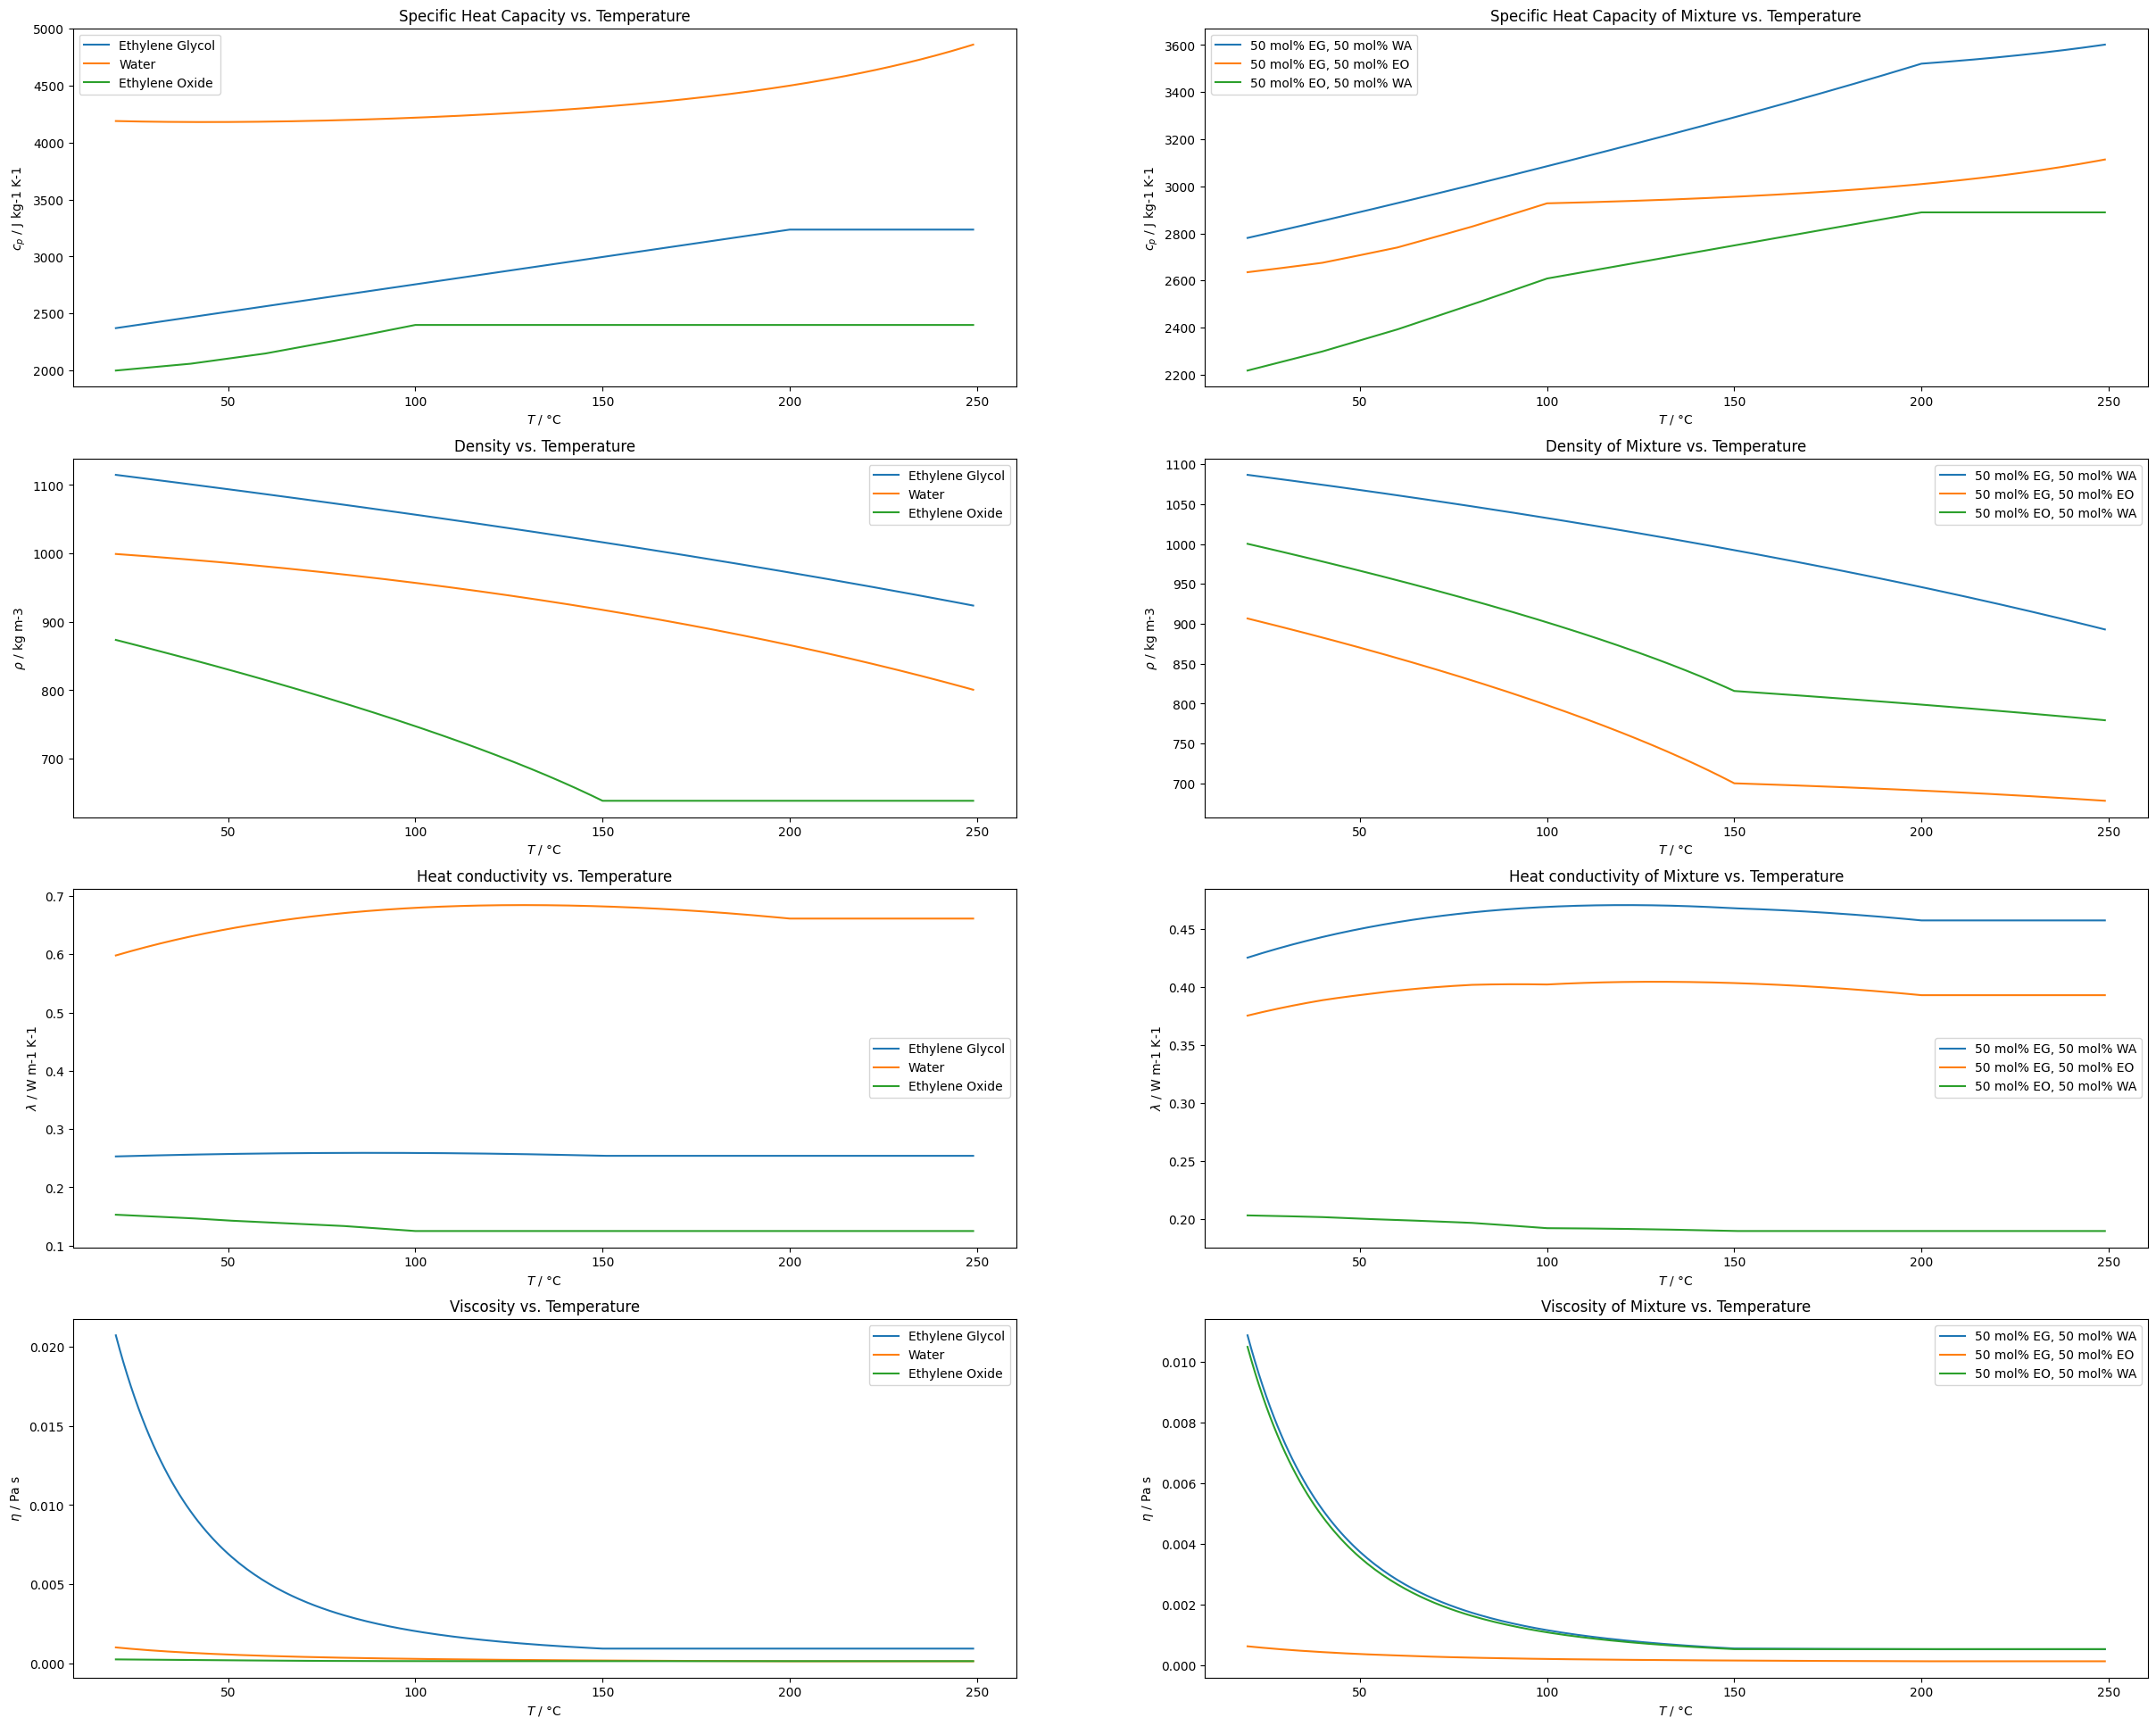

In [86]:
fig, ax = plt.subplots(nrows=4, ncols=2, figsize=(30, 24))
T_range = np.arange(20, 250, 1) + 273.15
ax[0, 0].plot(T_range - 273.15, c_p_EG(T_range), label='Ethylene Glycol')
ax[0, 0].plot(T_range - 273.15, c_p_WA(T_range), label='Water')
ax[0, 0].plot(T_range - 273.15, c_p_EO_interp(T_range), label='Ethylene Oxide')
ax[0, 0].set_xlabel(r'$T$ / °C')
ax[0, 0].set_ylabel(r'$c_p$ / J kg-1 K-1')
ax[0, 0].set_title('Specific Heat Capacity vs. Temperature')
ax[0, 0].legend()

ax[1, 0].plot(T_range - 273.15, rho_EG(T_range), label='Ethylene Glycol')
ax[1, 0].plot(T_range - 273.15, rho_WA(T_range), label='Water')
ax[1, 0].plot(T_range - 273.15, rho_EO(T_range), label='Ethylene Oxide')
ax[1, 0].set_xlabel(r'$T$ / °C')
ax[1, 0].set_ylabel(r'$\rho$ / kg m-3')
ax[1, 0].set_title('Density vs. Temperature')
ax[1, 0].legend()

ax[0, 1].plot(T_range - 273.15, c_p_mix(T_range,  np.array([0.5, 0.5, 0])), label='50 mol% EG, 50 mol% WA')
ax[0, 1].plot(T_range - 273.15, c_p_mix(T_range, np.array([0.5, 0, 0.5])), label='50 mol% EG, 50 mol% EO')
ax[0, 1].plot(T_range - 273.15, c_p_mix(T_range, np.array([0, 0.5, 0.5])), label='50 mol% EO, 50 mol% WA')
ax[0, 1].set_xlabel('$T$ / °C')
ax[0, 1].set_ylabel('$c_p$ / J kg-1 K-1')
ax[0, 1].set_title('Specific Heat Capacity of Mixture vs. Temperature')
ax[0, 1].legend() 

ax[1, 1].plot(T_range - 273.15, rho_mix(T_range, np.array([0.5, 0.5, 0])), label='50 mol% EG, 50 mol% WA')
ax[1, 1].plot(T_range - 273.15, rho_mix(T_range, np.array([0.5, 0, 0.5])), label='50 mol% EG, 50 mol% EO')
ax[1, 1].plot(T_range - 273.15, rho_mix(T_range, np.array([0, 0.5, 0.5])), label='50 mol% EO, 50 mol% WA')
ax[1, 1].set_xlabel(r'$T$ / °C')
ax[1, 1].set_ylabel(r'$\rho$ / kg m-3')
ax[1, 1].set_title('Density of Mixture vs. Temperature')
ax[1, 1].legend()

ax[2, 0].plot(T_range - 273.15, lambda_EG(T_range), label='Ethylene Glycol')
ax[2, 0].plot(T_range - 273.15, lambda_WA(T_range), label='Water')
ax[2, 0].plot(T_range - 273.15, lambda_EO_interp(T_range), label='Ethylene Oxide')
ax[2, 0].set_xlabel(r'$T$ / °C')
ax[2, 0].set_ylabel(r'$\lambda$ / W m-1 K-1')
ax[2, 0].set_title('Heat conductivity vs. Temperature')
ax[2, 0].legend()

ax[2, 1].plot(T_range - 273.15, lambda_mix(T_range, np.array([0.5, 0.5, 0])), label='50 mol% EG, 50 mol% WA')
ax[2, 1].plot(T_range - 273.15, lambda_mix(T_range, np.array([0.5, 0, 0.5])), label='50 mol% EG, 50 mol% EO')
ax[2, 1].plot(T_range - 273.15, lambda_mix(T_range, np.array([0, 0.5, 0.5])), label='50 mol% EO, 50 mol% WA')
ax[2, 1].set_xlabel(r'$T$ / °C')
ax[2, 1].set_ylabel(r'$\lambda$ / W m-1 K-1')
ax[2, 1].set_title('Heat conductivity of Mixture vs. Temperature')
ax[2, 1].legend()

ax[3, 0].plot(T_range - 273.15, eta_EG(T_range), label='Ethylene Glycol')
ax[3, 0].plot(T_range - 273.15, eta_WA(T_range), label='Water')
ax[3, 0].plot(T_range - 273.15, eta_EO_interp(T_range), label='Ethylene Oxide')
ax[3, 0].set_xlabel(r'$T$ / °C')
ax[3, 0].set_ylabel(r'$\eta$ / Pa s')
ax[3, 0].set_title('Viscosity vs. Temperature')
ax[3, 0].legend()

ax[3, 1].plot(T_range - 273.15, eta_mix(T_range, np.array([0.5, 0.5, 0])), label='50 mol% EG, 50 mol% WA')
ax[3, 1].plot(T_range - 273.15, eta_mix(T_range, np.array([0.5, 0, 0.5])), label='50 mol% EG, 50 mol% EO')
ax[3, 1].plot(T_range - 273.15, eta_mix(T_range, np.array([0, 0.5, 0.5])), label='50 mol% EO, 50 mol% WA')
ax[3, 1].set_xlabel(r'$T$ / °C')
ax[3, 1].set_ylabel(r'$\eta$ / Pa s')
ax[3, 1].set_title('Viscosity of Mixture vs. Temperature')
ax[3, 1].legend()

plt.show()

### 6.6 Converting concentrations to molar flows
For that first the mole fractions used in the thermodynamic models and the inlet molar flows of the injector model the given concentrations have to be converted (Equation 11). 

$$ \dot{n}_i = c_iA_{c}u \tag{11} $$

The concentration of water is generally not given. This leads to the need to calculate it directly. For that first the total molar flow has to be calculated using equations 12-14 and the scipy root solver.

$$ \dot{n}_{mix} = \frac{\dot{m}_{mix}}{M_{mix}} =  \frac{\rho_{mix} \dot{V}}{M_{mix}} = \frac{\rho_{mix} u A_{sqr}}{M_{mix}} \tag{12} $$

$$ \dot{n}_{mix} = \dot{n}_{EO} + \dot{n}_{EG} + \dot{n}_{WA} \tag{13} $$

$$ x_i = \frac{\dot{n}_{i} }{\dot{n}_{mix}} \tag{14} $$





In [87]:
# Calculated molar flow in mol s-1
def n_dot(u, rho, M):
    return u * rho * A_ref / (M * 0.001)

# Calculated liquid velocity in m s-1
def u(n_dot, rho, M):
    return n_dot * M / (rho * A_ref * 1000)

# Molar fraction calculated from concentrations
def x_i(c_arr, c_i):
    return c_i / np.sum(c_arr)

# Function for calculation molar flow of water in mol s-1 via root finding
def search_WA_inlet(n_dot_in_WA, n_dot_in_EO, T_0, u_ref):
    x_WA = n_dot_in_WA / (n_dot_in_WA + n_dot_in_EO)
    x_EO = n_dot_in_EO / (n_dot_in_WA + n_dot_in_EO)

    x_arr = np.array([x_WA[0], 0, x_EO[0]])

    u_ = u(n_dot_in_WA + n_dot_in_EO, rho_mix(T_0, x_arr), M_mix(x_arr))

    return u_ - u_ref

### 6.7 PFTR behavior with improved thermodynamics
The improved thermodynamic behavior is now applied to the PFTR model. Therefore, the volumetric heat capacity $C_{mix} = \rho_{mix} \cdot c_{p,mix}$ is replaced in the model. The change in fluid velocity $u$ is still assumed to be zero. This can be done because of the generally low coefficients of expansion $(\propto 10^{-4})$ [3]. 

In [88]:
# Modified ODE of the PFTR with improved thermodynamics
def PFTR_thermodynamics(L, f, u_ref, h):
    """
    Spatial derivatives for the PFTR material and energy balances.

    f[0] = c_1  (EO concentration, mol/m^3)
    f[1] = c_2  (EG concentration, mol/m^3)
    f[2] = c_3  (WA concentration, mol/m^3)
    f[3] = T    (temperature, K)

    Space-time transformation:  d/dL = (1/u) * d/dt
    Each right-hand side is the bSTR time-derivative divided by u.
    """
    c_1 = f[0]
    c_2 = f[1]
    c_3 = f[2]
    T   = f[3]

    c_arr = np.array([c_1, c_2, c_3])

    x_1 = x_i(c_arr, c_1)
    x_2 = x_i(c_arr, c_2)
    x_3 = x_i(c_arr, c_3)

    x_arr = np.array([x_3, x_2, x_1])


    r = kinetics(T, c_1)


    # Component balances (material balance per unit reactor length)
    dc_1dL = -r / u_ref
    dc_2dL =  r / u_ref
    dc_3dL = -r / u_ref

    C = c_p_mix(T, x_arr) * rho_mix(T, x_arr)

    # Energy balance per unit reactor length
    # Reaction term:    -H_R * r / C              [K/s] / [m/s] = K/m
    # Heat-transfer:    h_wall * a_wall * (T-T_wall) / C  [K/m]
    dTdL = (-H_R * r / C - h * a_wall * (T - T_wall) / C) / u_ref

    dfdL = np.empty_like(f)
    dfdL[0] = dc_1dL
    dfdL[1] = dc_2dL
    dfdL[2] = dc_3dL
    dfdL[3] = dTdL
    return dfdL

# Function for  calculating the initial condidion of water and solving the ODE
def sol_thermodynamics(c_arr, T_0, u_ref, h):
    c_EO = c_arr[0] # Concentration of EO in mol/m3
    c_EG = c_arr[1] # Concentration of EO in mol/m3


    n_dot_in_EO_tot = c_EO * u_ref * A_ref # Total molar flow rate of EO in mol/s
    n_dot_in_EG_tot = c_EG * u_ref * A_ref # Total molar flow rate of EO in mol/s

    n_dot_in_WA_initial_guess = n_dot_in_EO_tot # Initial guess for the molar flow rate of water in mol/s    

    n_dot_in_WA = root(search_WA_inlet, n_dot_in_WA_initial_guess, args=(n_dot_in_EO_tot, T_0, u_ref)).x[0] # Solve for the molar flow rate of water in mol/s

    c_WA = n_dot_in_WA / (u_ref * A_ref) # Concentration of water for iitial conditions in mol/m3

    initial = np.array([c_EO, c_EG, c_WA, T_0]) # Initial values for ODE

    sol_thermodynamic = solve_ivp(PFTR_thermodynamics, Lspan, initial, method='LSODA',args=(u_ref, h), t_eval=leval)

    return sol_thermodynamic.t, sol_thermodynamic.y[0], sol_thermodynamic.y[1], sol_thermodynamic.y[2], sol_thermodynamic.y[3] 

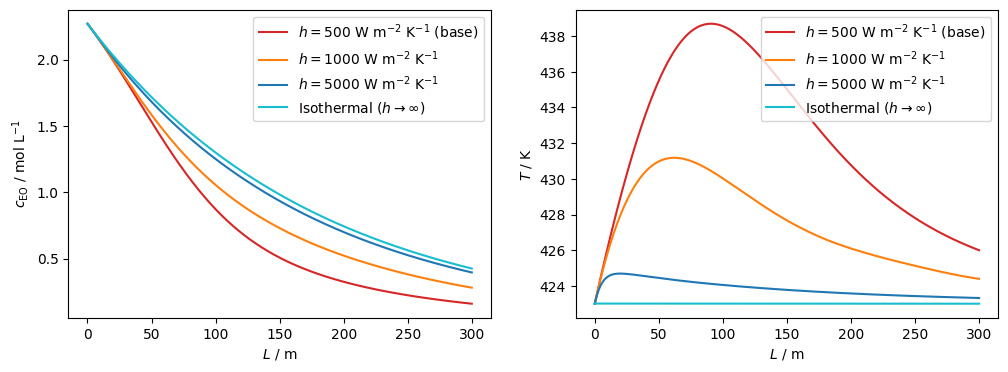

In [89]:
h_cases = {
    '$h = 500$ W m$^{-2}$ K$^{-1}$ (base)': 500,
    '$h = 1000$ W m$^{-2}$ K$^{-1}$': 1000,
    '$h = 5000$ W m$^{-2}$ K$^{-1}$':       5000,
    'Isothermal ($h \\to \\infty$)':         1e6,
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.set(xlabel='$L$ / m', ylabel='$c_{\\mathrm{EO}}$ / mol L$^{-1}$')
ax2.set(xlabel='$L$ / m', ylabel='$T$ / K')
colors = ['tab:red', 'tab:orange', 'tab:blue', 'tab:cyan', 'tab:green']

for (label, h), color in zip(h_cases.items(), colors):
    f_init = np.array([c_10, c_20, T_0])
    sol = sol_thermodynamics(np.array([c_10, c_20]), T_0, u_ref, h)
    ax1.plot(sol[0], sol[1] / 1000, color=color, label=label)
    #ax1.plot(sol[0], sol[2] / 1000, color=color, label=label)
    ax2.plot(sol[0], sol[4],         color=color, label=label)

ax1.legend(loc="best")
ax2.legend(loc="best")

If these results are compared to the PFTR with simplified thermodynamics, there is a higher resulting temperature maximum. This can be explained due to the lower volumetric heat capacity $C_{mix} = c_{p,mix} \cdot \rho_{mix}$ which leads to a higher temperature gradient. This shows that simplifying the thermodynamics leads to an underestimation of the local temperatures and thus the possibility to cross safety limits.

### 7 Improvement of reaction control using multiple injectors
One common way in process intensification to control a strongly exothermic reaction is injecting one of the reagents multiple times instead of both reagents at the beginning. This is done because it gives the stream time to get cooled in between injections and thus has the potential to lower or contain the previously observed temperature peaks. For thermodynamics the improved thermodynamics were used.

First the distance $\Delta L$ between the injectors has to be calculated. This is done using the number of injectors $N$ (Equation 15). This number doesn't include the initial injector. The total number of injectors is $N+1$.

$$ \Delta L = \frac{L}{N + 1}  \tag{15} $$

Using the distance between the injectors, the location of injector $i$, $x_{inj, i}$ can be calculated using Equation 16. 

$$ x_{inj, i} =  i \cdot \Delta L \tag{16} $$

Assuming every injection point gets the same amount of reactant, the amount per injector $\dot{n}_{EO, injector}$ is calculated using Equation 17. Due to the difference in concentrations of EO and Water, EO was chosen as injected species. 

$$ \dot{n}_{EO, injector} = \frac{\dot{n}_{EO, in}}{N + 1} \tag{17} $$

For describing the behavior mathematically, molar flow balances are more favorable (Equation 18). A PFTR with multiple injections can be described by multiple consecutive PFTRs with the injector being mixed with the outgoing stream from the previous PFTR. Thus the ODE gets solved for each section. Except for the first section, each initial value was described by the outgoing molar streams of the previous section and the added injection molar streams.

$$ \frac{d\dot{n}_i}{dx} = \nu_i r A_{c} \tag{18}$$

For solving the ODEs, the previous solver and methods were used. Also the kinetics were unchanged. 

In [90]:
A_ref = np.pi * (d_R/2) ** 2 # Crosssection are of the PFTR in m 2

# Calculate the locations for the injectors
def injection_locations(L, N):
    delta_L = L / (N + 1)
    loc = []
    for i in range(1, N + 1):
        loc.append(i*delta_L)
    return loc

# Calculate the molar flow of the PFTR at the reactor inlet in mol/s
def initial_injection(n_dot_in_EO , N):
    return n_dot_in_EO / (N + 1) # Initial flow rate of EO at the first injection point

# ODE for the PFTR including the improved thermodynamics and now based on molar flows
def PFTR_inj(x, f, h, T_w):
    n_dot_WA = f[0]
    n_dot_EG = f[1]
    n_dot_EO = f[2] 
    T = f[3]

    x_WA = n_dot_WA / (n_dot_WA + n_dot_EG + n_dot_EO)
    x_EG = n_dot_EG / (n_dot_WA + n_dot_EG + n_dot_EO)
    x_EO = n_dot_EO / (n_dot_WA + n_dot_EG + n_dot_EO)

    rho_ = rho_mix(T, np.array([x_WA, x_EG, x_EO]))
    c_p_ = c_p_mix(T, np.array([x_WA, x_EG, x_EO])) 

    C = rho_ * c_p_


    u_ = u(n_dot_WA + n_dot_EG + n_dot_EO, rho_mix(T, np.array([x_WA, x_EG, x_EO])), M_mix(np.array([x_WA, x_EG, x_EO])))

    r = kinetics(T, n_dot_EO / (A_ref*u_))

    dn_EO_dotdx = -r * A_ref
    dn_EG_dotdx = r * A_ref
    dn_WA_dotdx = -r * A_ref

    dTdL = (-H_R * r) / (C * u_) - h * a_wall * (T - T_w) / (C * u_)

    dfdL = np.empty_like(f)
    dfdL[0] = dn_WA_dotdx
    dfdL[1] = dn_EG_dotdx
    dfdL[2] = dn_EO_dotdx
    dfdL[3] = dTdL

    return dfdL

delta_x = 0.1
x_prev = 0
L_arr = np.arange(0, L_R, delta_x)

# New temperature after mixing the injector stream with the stream from the PFTR in K
def T_mix(T_new, n_dot_WA_out, n_dot_EO_out, n_dot_EG_out, n_dot_EO_inj, T_inj, T_0):
        
        n_dot_tot = n_dot_WA_out[-1] + n_dot_EO_out[-1] + n_dot_EG_out[-1]
        x_EO_out_ = n_dot_EO_out[-1] / n_dot_tot
        x_EG_out_ = n_dot_EG_out[-1] / n_dot_tot
        x_WA_out_ = n_dot_WA_out[-1] / n_dot_tot

        c_p_mix_out = c_p_mix(T_inj[-1], np.array([x_WA_out_, x_EG_out_, x_EO_out_])) 


        n_dot_tot_new = n_dot_WA_out[-1] + n_dot_EO_out[-1] + n_dot_EG_out[-1] + n_dot_EO_inj
        x_EO_out_new = (n_dot_EO_out[-1] + n_dot_EO_inj) / n_dot_tot_new
        x_EG_out_new = n_dot_EG_out[-1] / n_dot_tot_new
        x_WA_out_new = n_dot_WA_out[-1] / n_dot_tot_new

        M_mix_out = M_mix(np.array([x_WA_out_, x_EG_out_, x_EO_out_]))
        M_mix_out_new = M_mix(np.array([x_WA_out_new, x_EG_out_new, x_EO_out_new]))

        c_p_mix_new = c_p_mix(T_new, np.array([x_WA_out_new, x_EG_out_new, x_EO_out_new])) 

        m_dot_EO_inj = n_dot_EO_inj * M_EO * 10 ** (-3)
        m_dot_out_tot = n_dot_tot * M_mix_out * 10 ** (-3)
        m_dot_out_tot_new = n_dot_tot_new * M_mix_out_new * 10 ** (-3)

        diff = T_new - (m_dot_out_tot* c_p_mix_out * T_inj[-1] + m_dot_EO_inj * c_p_EO_interp(T_0) * T_0) / (m_dot_out_tot_new * c_p_mix_new)

        return diff



# Calculation of PFTR with improved thermodynamics and injectors
def sol_inject(c_arr, T_0, N, h):
    c_EO = c_arr[0]
    c_EG = c_arr[1]


    n_dot_in_EO_tot = c_EO * u_ref * A_ref # Total molar flow rate of EO in mol/s
    n_dot_in_EG_tot = c_EG * u_ref * A_ref # Total molar flow rate of EO in mol/s

    x_arr_inj = injection_locations(L_R, N)
    n_dot_in_EO_injection = n_dot_in_EO_tot / (N + 1) # Flow rate of EO at each injection point

    arr = {} # x array for each section

    delta_L = L_R / (N + 1)

    # Calculating the x array for each section
    for i, x_i in enumerate(x_arr_inj):
        t_arr = np.arange(i*delta_L, (i+1)*delta_L, 0.1)
        arr.update({f"{i}": t_arr})

    numb = N 


    arr.update({f"{numb}": np.arange(numb*delta_L, (numb+1)*delta_L, 0.1)}) # Adding one section due to N + 2 sections required

    n_dot_in_EO = initial_injection(n_dot_in_EO_tot, N) # Molar flow rate of EO at each injection point in mol/s

    n_dot_in_WA_initial_guess = n_dot_in_EO # Initial guess for the molar flow rate of water in mol/s    

    n_dot_in_WA = root(search_WA_inlet, n_dot_in_WA_initial_guess, args=(n_dot_in_EO, T_0, 1)).x[0] # Solve for the molar flow rate of water in mol/s

    n_dot_WA_out = np.array([n_dot_in_WA]) # Resulting molar flow profile of water in mol/s
    n_dot_EG_out = np.array([0]) # Resulting molar flow profile of EG in mol/s
    n_dot_EO_out = np.array([0]) # Resulting molar flow profile of EO in mol/s
    T_inj = np.array([T_0]) # Resulting temperature profile in K
    t = np.array([0])

    # Solving the ODE for each section of the PFTR
    for i in arr.keys():
        L_arr = arr[f"{i}"]

        T_w = T_0


        if int(i) > 0:
            T_mix_ = root(T_mix, T_inj[-1], args=(n_dot_WA_out, n_dot_EO_out, n_dot_EG_out, n_dot_in_EO, T_inj, T_0)).x[0]

        else:
            T_mix_ = T_0

        initial = np.array([n_dot_WA_out[-1], n_dot_EG_out[-1], n_dot_EO_out[-1] + n_dot_in_EO , T_mix_])
        sol_inj = solve_ivp(PFTR_inj, np.array([L_arr[0], L_arr[-1]]), initial, t_eval=L_arr, method="BDF", max_step=0.1, args=(h, T_w))

        t = np.append(t , sol_inj.t)
        n_dot_WA_out = np.append(n_dot_WA_out, sol_inj.y[0])
        n_dot_EG_out = np.append(n_dot_EG_out, sol_inj.y[1])
        n_dot_EO_out = np.append(n_dot_EO_out, sol_inj.y[2])
        T_inj = np.append(T_inj, sol_inj.y[3])


    x_WA_inj_out = n_dot_WA_out / (n_dot_WA_out + n_dot_EO_out + n_dot_EG_out) # Mole fraction profile of water in the resulting stream
    x_EO_inj_out = n_dot_EO_out / (n_dot_WA_out + n_dot_EO_out + n_dot_EG_out) # Mole fraction profile of EO in the resulting stream
    x_EG_inj_out = n_dot_EG_out / (n_dot_WA_out + n_dot_EO_out + n_dot_EG_out) # Mole fraction profile of EG in the resulting stream


    u_ = u(n_dot_WA_out+n_dot_EG_out+n_dot_EO_out, rho_mix(T_inj, np.array([x_WA_inj_out, x_EG_inj_out, x_EO_inj_out])), M_mix(np.array([x_WA_inj_out, x_EG_inj_out, x_EO_inj_out]))) # Velocity profile of the resulting stream profile
    
    return t, n_dot_WA_out / (u_ * A_ref), n_dot_EG_out / (u_ * A_ref), n_dot_EO_out / (u_ * A_ref), T_inj, u_



### 7.1 Influence of different heat transfer coefficients 
Because the injector PFTR improves heat transfer, lower wall heat transfer coefficients $h_{wall}$ may be sufficient. It is therefore important to determine how low the heat transfer coefficient can be before temperature rises sharply. Furthermore, a higher inlet temperature $T_0$ is chosen to bring the system closer to a more optimal operating point. 

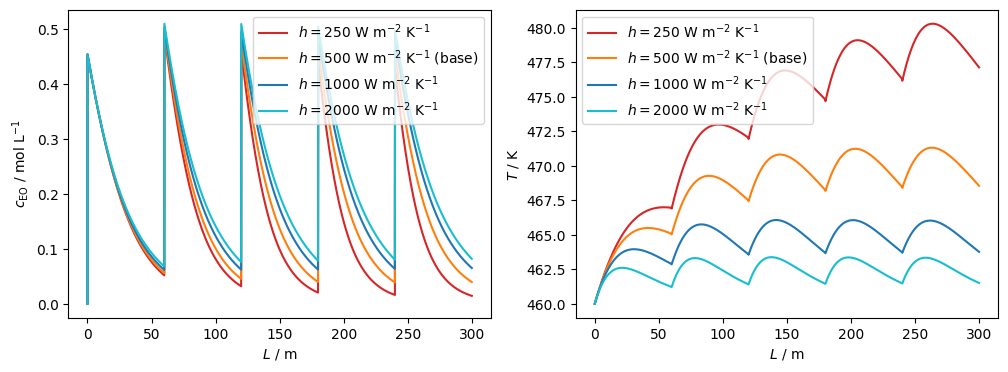

In [91]:
h_cases_inj = {
    '$h = 250$ W m$^{-2}$ K$^{-1}$': 250,
    '$h = 500$ W m$^{-2}$ K$^{-1}$ (base)': 500,
    '$h = 1000$ W m$^{-2}$ K$^{-1}$': 1000,
    '$h = 2000$ W m$^{-2}$ K$^{-1}$': 2000,
}


fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(12, 4))
ax3.set(xlabel='$L$ / m', ylabel='$c_{\\mathrm{EO}}$ / mol L$^{-1}$')
ax4.set(xlabel='$L$ / m', ylabel='$T$ / K')
colors = ['tab:red', 'tab:orange', 'tab:blue', 'tab:cyan', 'tab:green']

for (label, h), color in zip(h_cases_inj.items(), colors):
    sol_inj = sol_inject(np.array([c_10, c_20]), 460, 4, h)
    ax3.plot(sol_inj[0], sol_inj[3] / 1000, color=color, label=label)
    #ax3.plot(sol_inj[0], sol_inj[2] / 1000, color=color, label=label)
    ax4.plot(sol_inj[0], sol_inj[4],         color=color, label=label)

ax3.legend(loc="best")
ax4.legend(loc="best")

plt.show()

Here it can be seen that concentrations decline strongly between injection points. Furthermore a lower heat transfer coefficient leads to a higher reactant consumption. Comparing this with the temperature behavior, the higher heat transfer coefficients keep the temperature closer to the setpoint, while the lower coefficient cannot prevent the temperature increase. Thus, the temperature rise leads to greater reactant consumption.

### 7.2 Influence of the amount of injectors
Now it is important to look at the effect of different numbers of injectors. This is important because a higher number of injectors has the potential of increasing reaction control. 

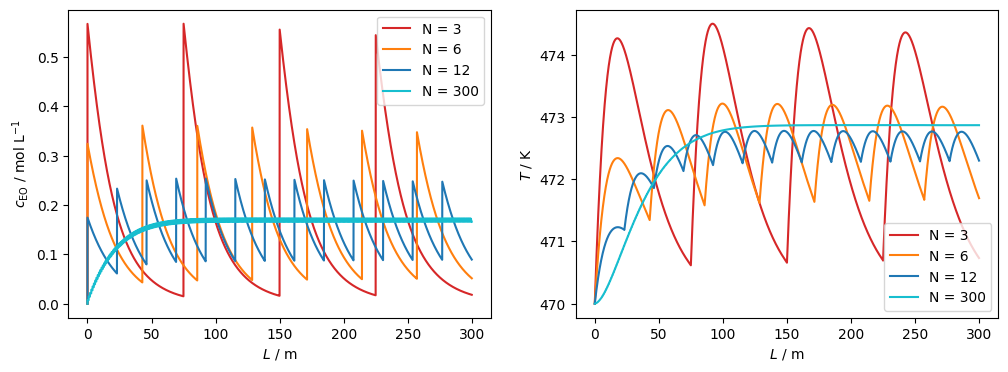

In [92]:
N_cases = {
    "N = 3": 3,
    "N = 6": 6,
    "N = 12": 12,
    "N = 300": 300,
}

fig3, (ax5, ax6) = plt.subplots(1, 2, figsize=(12, 4))
ax5.set(xlabel='$L$ / m', ylabel='$c_{\\mathrm{EO}}$ / mol L$^{-1}$')
ax6.set(xlabel='$L$ / m', ylabel='$T$ / K')
colors = ['tab:red', 'tab:orange', 'tab:blue', 'tab:cyan', 'tab:green']

for (label, N), color in zip(N_cases.items(), colors):
    sol_inj_c = sol_inject(np.array([c_10, c_20]), 470, N, 2000)

    ax5.plot(sol_inj_c[0], sol_inj_c[3] / 1000, color=color, label=label)
    ax6.plot(sol_inj_c[0], sol_inj_c[4],         color=color, label=label)

ax5.legend(loc="best")
ax6.legend(loc="best")

plt.show()

Here it can be seen that with a larger number of injectors the PFTR behavior approaches a smooth curve. This can be explained by that the PFTR approaches the behavior of a semi-continuous batch reactor as $N \to \infty$. Thus it can be said that a higher number of injectors improves reaction control and thus fulfills the requirements of process intensification. 

### 7.3 Optimization of the PFTR with injectors
Now it is important to determine how large the temperature increase is relative to conversion. This is a typical case of process control versus process performance. Higher temperatures lead to higher thermal requirements for the reactor and a greater risk of increased production of side products.

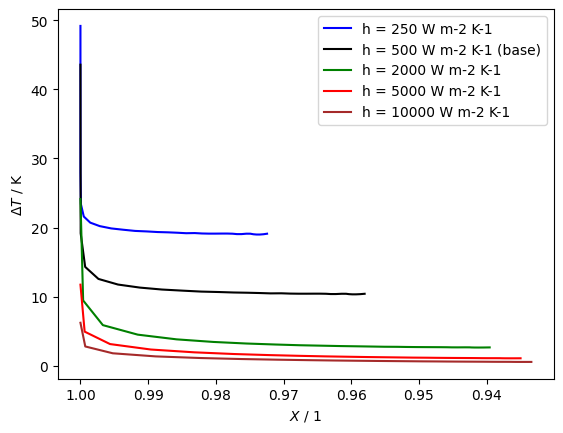

In [93]:
fig_par, ax_par = plt.subplots()

ax_par.invert_xaxis()

h_arr = np.array([250, 500, 2000, 5000, 10000]) # Array of heat transfer coefficient in W m-2 K-1
N_arr = np.arange(0, 30, 1) # Array of number of injectors

color = ["blue", "black", "green", "red", "brown"]
label = [r"h = 250 W m-2 K-1", r"h = 500 W m-2 K-1 (base)", r"h = 2000 W m-2 K-1", r"h = 5000 W m-2 K-1", r"h = 10000 W m-2 K-1"]

for i, h in enumerate(h_arr):
    U_final_N = np.array([])
    delta_T_N = np.array([])
    for N in N_arr:
        sol_inj_c = sol_inject(np.array([c_10, c_20]), 470, N, h) # Solving the ODE 

        n_dot_in_EO_tot = c_10 * u_ref * A_ref # Total molar flow of EO added of each case
        n_dot_EO_out = sol_inj_c[3][-1] * sol_inj_c[5][-1] * A_ref # Outgoing stream of EO at the exit of the PFTR of each case

        len_arr = len(sol_inj_c[4])

        U_final = (n_dot_in_EO_tot - n_dot_EO_out) / n_dot_in_EO_tot # Conversion at the exit of the PFTR of each case
        delta_T =  np.max(sol_inj_c[4]) - 470 # Deviations from temperature setpoint in K

        U_final_N = np.append(U_final_N, U_final)
        delta_T_N = np.append(delta_T_N, delta_T)

    ax_par.plot(U_final_N, delta_T_N, color=color[i], label=label[i])
    ax_par.set(xlabel=r"$X$ / 1", ylabel=r"$\Delta T$ / K")

ax_par.legend(loc="best")
plt.show()


The optimization seems to form a variety of Pareto fronts, which are typical for multi-objective optimization and show the limits of process intensification. This indicates that injectors are needed in the case of poor heat exchange performance and also means, that if the reaction is more exothermic than assumed, injectors are still needed to control temperature. 

### 8 Realistic heat transfer coefficients

The heat transfer coefficient $h$ is strongly dependent on the geometry of the reactor.
The diameter affects both the $h$ and the surface area of the reactor. Changing the diameter drastically changes the performance of the reactor.

For the following the correlation for the Nusselt number based on Petukhov are taken from the VDI-Heataltas [3].
It is assumed, that the thermal conductivity of the reactor material, the heat transfer coefficient and the amount of coolant on the outside of the reactor are not the limiting factors.
A full implementation of those result in overly extensive code and unnecessary complexity.
Therefore only the effect of the diameter is evaluated here.

For the first step the fluid velocity is kept constant at the 1m/s as given at the start of this assignment.
The second step keeps the volumetric flow rate constant and changes the fluid velocity based on the diameter.

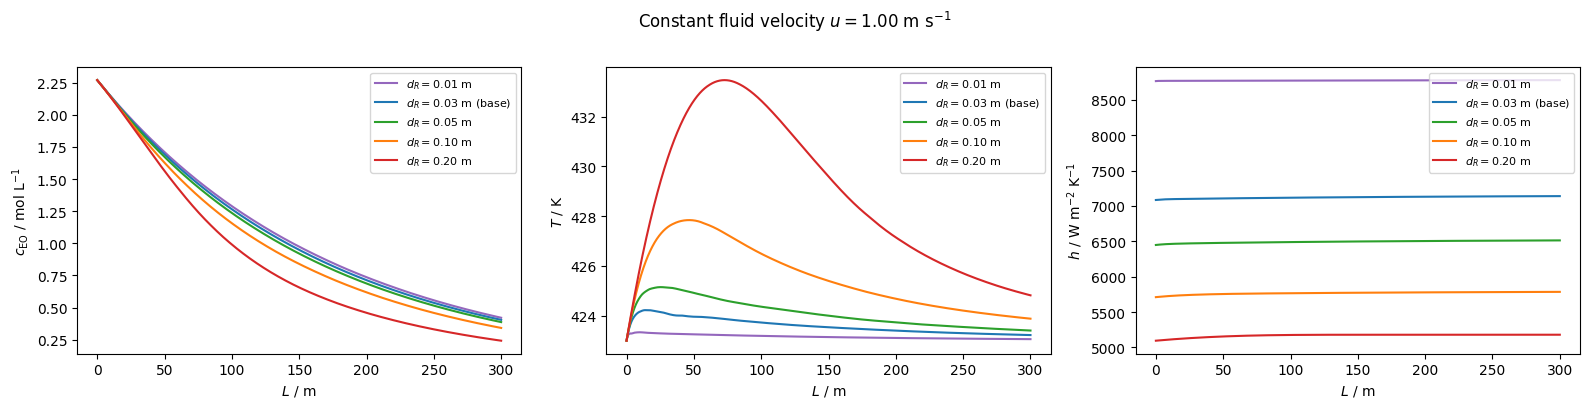

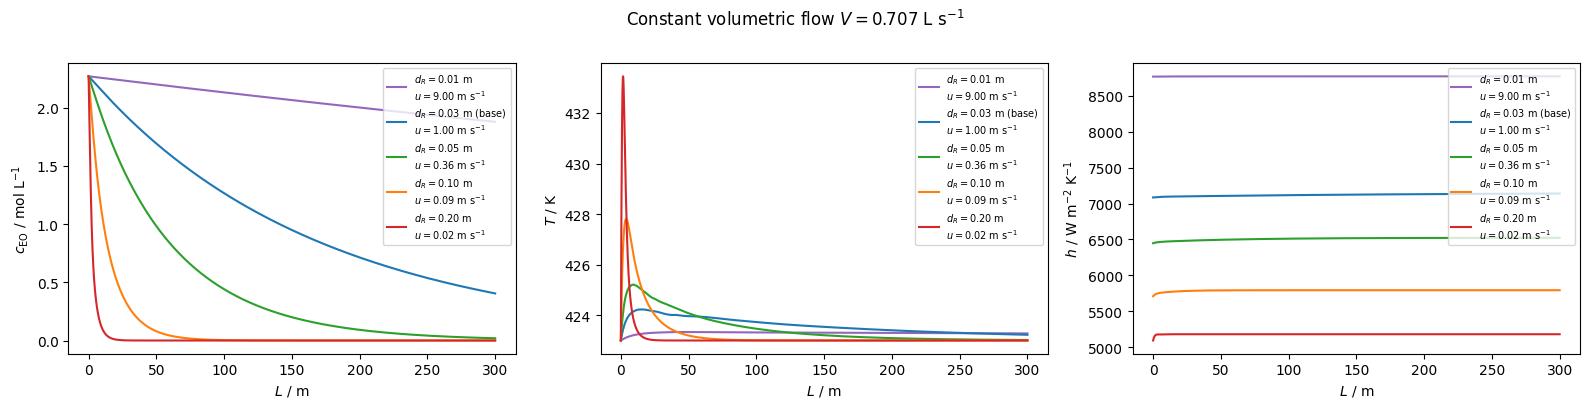

In [94]:
# Initial water concentration from density balance
# rho_mix ≈ 1000 kg/m³ → mass of WA = rho - c_EO*M_EO/1000
c_WA_0 = (rho - c_10 * M_EO / 1000) / (M_WA / 1000)  # mol/m³  ≈ 49970

def h_by_petukov(T, x, d_R):
    Re = rho_mix(T, x) * u_ref * d_R / eta_mix(T, x)
    Pr = eta_mix(T, x) * c_p_mix(T, x) / lambda_mix(T, x)
    xi = np.power(1.8 * np.log10(Re) - 1.5, -2)
    Nu = np.divide(((xi/8) * (Re - 1000) * Pr),(1 + 12.7 * np.power(xi/8, 0.5) * (np.power(Pr, 2/3) - 1))) * (1 + np.power(d_R / L_R, 2/3))
    h = Nu * lambda_mix(T, x) / d_R
    return h


def PFTR_petukhov(L, f, d):
    """
    PFTR with Petukhov h, tracking EO, EG, H2O, T.
    f[0] = c_EO  (mol/m³)
    f[1] = c_EG  (mol/m³)
    f[2] = c_WA  (mol/m³)
    f[3] = T     (K)
    d    = tube diameter (m)
    """
    c_EO, c_EG, c_WA, T = f[0], f[1], f[2], f[3]

    # Mole fractions for mixture properties  [x_WA, x_EG, x_EO]
    c_tot = c_EO + c_EG + c_WA
    x_arr = np.array([c_WA / c_tot, c_EG / c_tot, c_EO / c_tot])

    # Position-dependent h and a_wall for this diameter
    h  = h_by_petukov(T, x_arr, d)
    a  = 4 / d                                          # specific wall area m²/m³

    # Composition-dependent volumetric heat capacity
    C_mix = rho_mix(T, x_arr) * c_p_mix(T, x_arr)     # J/(m³ K)

    r = kinetics(T, c_EO)

    dc_EOdL = -r / u_ref
    dc_EGdL =  r / u_ref
    dc_WAdL = -r / u_ref   # water consumed 1:1 with EO

    dTdL = (-H_R * r / C_mix - h * a * (T - T_wall) / C_mix) / u_ref

    return np.array([dc_EOdL, dc_EGdL, dc_WAdL, dTdL])


d_cases = {
    '$d_R = 0.01$ m':        0.01,
    '$d_R = 0.03$ m (base)': 0.03,
    '$d_R = 0.05$ m':        0.05,
    '$d_R = 0.10$ m':        0.10,
    '$d_R = 0.20$ m':        0.20,
}

f_init_4 = np.array([c_10, c_20, c_WA_0, T_0])
colors   = ['tab:purple', 'tab:blue', 'tab:green', 'tab:orange', 'tab:red']

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))
ax1.set(xlabel='$L$ / m', ylabel='$c_{\\mathrm{EO}}$ / mol L$^{-1}$')
ax2.set(xlabel='$L$ / m', ylabel='$T$ / K')
ax3.set(xlabel='$L$ / m', ylabel='$h$ / W m$^{-2}$ K$^{-1}$')

for (label, d), color in zip(d_cases.items(), colors):
    sol = integ.solve_ivp(
        PFTR_petukhov, Lspan, f_init_4,
        args=(d,), method='BDF', t_eval=leval
    )

    # Reconstruct h along the reactor for the third panel
    c_tot = sol.y[0] + sol.y[1] + sol.y[2]
    x_WA  = sol.y[2] / c_tot
    x_EG  = sol.y[1] / c_tot
    x_EO  = sol.y[0] / c_tot
    T_sol = sol.y[3]
    h_sol = np.array([
        h_by_petukov(T_sol[i], np.array([x_WA[i], x_EG[i], x_EO[i]]), d)
        for i in range(len(sol.t))
    ])

    ax1.plot(sol.t, sol.y[0] / 1000,  color=color, label=label)
    ax2.plot(sol.t, T_sol,             color=color, label=label)
    ax3.plot(sol.t, h_sol,             color=color, label=label)

for ax in (ax1, ax2, ax3):
    ax.legend(fontsize=8)
fig.suptitle(f'Constant fluid velocity $u = {u_ref:.2f}$ m s$^{{-1}}$', y=1.01)
fig.tight_layout()
plt.show()

#Tube Diameter — constant volumetric flow rate V

# Base volumetric flow from the base case (d_R=0.03, u=1.0 m/s)
V_base = u_ref * np.pi * (d_R / 2)**2   # m³/s  ≈ 7.07e-4

def PFTR_petukhov_V(L, f, d, u_d):
    """
    Same as PFTR_petukhov but with variable fluid velocity u_d,
    used for constant-V diameter sensitivity.
    """
    c_EO, c_EG, c_WA, T = f[0], f[1], f[2], f[3]

    c_tot = c_EO + c_EG + c_WA
    x_arr = np.array([c_WA / c_tot, c_EG / c_tot, c_EO / c_tot])

    h  = h_by_petukov(T, x_arr, d)
    a  = 4 / d
    C_mix = rho_mix(T, x_arr) * c_p_mix(T, x_arr)

    r = kinetics(T, c_EO)

    dc_EOdL = -r / u_d
    dc_EGdL =  r / u_d
    dc_WAdL = -r / u_d
    dTdL    = (-H_R * r / C_mix - h * a * (T - T_wall) / C_mix) / u_d

    return np.array([dc_EOdL, dc_EGdL, dc_WAdL, dTdL])


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))
ax1.set(xlabel='$L$ / m', ylabel='$c_{\\mathrm{EO}}$ / mol L$^{-1}$')
ax2.set(xlabel='$L$ / m', ylabel='$T$ / K')
ax3.set(xlabel='$L$ / m', ylabel='$h$ / W m$^{-2}$ K$^{-1}$')

for (label, d), color in zip(d_cases.items(), colors):
    u_d = V_base / (np.pi * (d / 2)**2)   # velocity for this diameter at constant V

    sol = integ.solve_ivp(
        PFTR_petukhov_V, Lspan, f_init_4,
        args=(d, u_d), method='BDF', t_eval=leval
    )

    c_tot = sol.y[0] + sol.y[1] + sol.y[2]
    x_WA  = sol.y[2] / c_tot
    x_EG  = sol.y[1] / c_tot
    x_EO  = sol.y[0] / c_tot
    T_sol = sol.y[3]
    h_sol = np.array([
        h_by_petukov(T_sol[i], np.array([x_WA[i], x_EG[i], x_EO[i]]), d)
        for i in range(len(sol.t))
    ])

    # Add velocity to the label so the difference is immediately visible
    label_V = label + f'\n$u = {u_d:.2f}$ m s$^{{-1}}$'
    ax1.plot(sol.t, sol.y[0] / 1000, color=color, label=label_V)
    ax2.plot(sol.t, T_sol,            color=color, label=label_V)
    ax3.plot(sol.t, h_sol,            color=color, label=label_V)

for ax in (ax1, ax2, ax3):
    ax.legend(fontsize=7)
fig.suptitle(f'Constant volumetric flow $V = {V_base*1000:.3f}$ L s$^{{-1}}$', y=1.01)
fig.tight_layout()
plt.show()

Based on the correlation, the given heat transfer coefficient of $500 \;\text{W/m}^2\text{K}$ are far below the actual value of around $7100 \;\text{W/m}^2\text{K}$ for the same geometry.
For the same fluid velocity, reducing the diameter to $0.01 \;\text{m}$ gives a similar reaction profile with very similar concentration and conversion, however enhances the temperature significantly with a heat transfer coefficient of around $8800  \; \text{W/m}^2\text{K}$.
Taking a diameter of $0.2  \;\text{m}$ the heat transfer coefficient drops to around $5200 \;\text{W/m}^2\text{K}$, however the overall conversion is higher due to the higher overall temperature in the larger reactor.

For the same volumetric flow rate the conversion for larger diameters than $0.03  \;\text{m}$ is almost $100 \;\%$, due to the overall higher temperature.
For smaller diameters the conversion drops significantly due to the much higher fluid velocity and therefore lower residence times.

## 9 Industrial Application

The reaction studied in this work is the hydrolysis of ethylene oxide (EO) to ethylene glycol (EG):

$$ C₂H₄O + H₂O → C₂H₆O₂$$

Ethylene glycol (EG) is an important large-scale industrial chemical with a global annual production of several million tons. The largest application of ethylene glycol is in the manufacture of polyethylene terephthalate (PET), which is widely used for beverage bottles, food packaging materials, and polyester fibers in the textile industry. Approximately half of the global ethylene glycol production is consumed in polyester manufacturing.

Another major application of ethylene glycol is as an antifreeze and coolant in automotive engines due to its low freezing point and high boiling point. It is also used in heat-transfer fluids for industrial cooling and heating systems. In addition, ethylene glycol serves as a raw material for the production of resins, polymers, solvents, hydraulic fluids, and various specialty chemicals.

Industrial production of ethylene glycol is commonly carried out through the hydrolysis of ethylene oxide in tubular reactors under controlled operating conditions. Since the reaction is exothermic, temperature control and heat removal play an important role in maintaining safe operation and achieving high conversion. Therefore, reactor design, inlet conditions, fluid velocity, and heat-transfer characteristics significantly influence process performance and product yield.

The widespread use of ethylene glycol in plastics, textiles, automotive applications, and chemical manufacturing makes this reaction highly relevant for industrial reactor design and process optimization [1,2].


## 10 Scientific Discussion

The simulation results show that the hydrolysis of ethylene oxide (EO) in the plug flow tubular reactor (PFTR) is strongly influenced by the reactor operating conditions, particularly the heat transfer coefficient, inlet temperature, inlet concentration, and fluid velocity. Since the reaction is exothermic, the temperature initially increases due to the heat released by the reaction. As the reactants are consumed and heat is removed through the reactor wall, the temperature gradually decreases along the reactor length [1,4].

The sensitivity analysis demonstrates that increasing the wall heat transfer coefficient improves heat removal and suppresses the temperature peak inside the reactor. Consequently, the reactor operates closer to isothermal conditions, leading to safer operation and improved temperature control. In contrast, adiabatic operation results in the highest temperature rise, which may increase the risk of thermal runaway in industrial reactors [3].

The inlet concentration of ethylene oxide has a significant influence on reactor behaviour. Higher inlet concentrations produce higher reaction rates and greater heat generation, resulting in a larger temperature increase and faster reactant conversion. Similarly, increasing the inlet temperature accelerates the reaction kinetics according to the Arrhenius equation, causing ethylene oxide to be consumed more rapidly while also increasing the maximum reactor temperature.

The influence of fluid velocity is related to the residence time inside the reactor. Lower fluid velocities increase the residence time, allowing more complete conversion of ethylene oxide, whereas higher velocities reduce the residence time and therefore decrease the overall conversion. These results demonstrate the importance of selecting suitable operating conditions to achieve high conversion while maintaining safe reactor temperatures.

## 11 Conclusion

The PFTR model successfully describes the coupled mass and energy balances for the hydrolysis of ethylene oxide to ethylene glycol. The numerical simulations provide valuable insight into the influence of operating parameters on concentration and temperature profiles along the reactor.

The results indicate that reactor performance depends strongly on the heat transfer coefficient, inlet temperature, inlet concentration, and fluid velocity. Efficient heat removal reduces the temperature peak and improves reactor safety, while higher inlet temperatures and concentrations increase the reaction rate and accelerate ethylene oxide conversion. In addition, lower fluid velocities increase the residence time, resulting in higher conversion of the reactant.

The sensitivity analyses demonstrate that proper selection of reactor operating conditions is essential to balance reaction rate, conversion, and temperature control. These findings are directly relevant for the industrial design and operation of tubular reactors used for ethylene oxide hydrolysis and similar exothermic liquid-phase reactions.

Overall, the developed PFTR model provides a useful framework for analysing reactor behaviour and can be further extended by including more detailed reaction kinetics, variable physical properties or additional transport effects to improve the accuracy of industrial reactor simulations.

## References

1. Rebsdat, S., & Mayer, D. (2012). Ethylene Glycol. In Ullmann's Encyclopedia of Industrial Chemistry. Wiley-VCH Verlag GmbH & Co. KGaA. DOI: 10.1002/14356007.a10_101.pub2.

2. Dye, R. F. *Ethylene Glycols Technology*. Huntsman Corporation, Sugar Land, TX 77478, USA.

3. *VDI Heat Atlas*. Edited by Ernst-Ulrich Schlünder and Volker Gnielinski. Springer, Berlin Heidelberg, 2010. ISBN: 978-3-540-77876-9.

4. Ashraf, F., Ajmal, M. S., Danish, M., & Khan, Q. S. *Production of Mono Ethylene Glycol by Hydrolysis of Ethylene Oxide*. Chemical Engineers.


## AI Use

**1. Tools used**

Claude Sonnet 4.6 , June 2026\
ChatGPT, June 2026\
Gemini, June 2026\
GitHub Copilot in VS Code, June 2026

**2. Areas of use**

| Subtask | AI |
|---|---|
| Code debugging | Yes |
| Code generation | Yes |
| Concept explanation | Yes |
| Language editing of report | Yes |
| Text generation | No |
| Logic | No |

**3. Prompting strategy**

A usual prompt has the following structure:
1) Current state. This might include current code, an error message or a description of a certain task.
2) Own Idea. This might include possible functions to use, a certain logic to follow or may be skipped in case of an error message.
3) Task. What the AI should do. This may include error solving, code generation in a certain logic or explanation of functions or concepts.

**4. Critical examination**

All AI outputs are always read carefully and not copied blindly.
Any output that is not explicitly asked for is not used.


**5. Statement of own contribution**

The implementation of the thermodynamic parameters, the building of the correct equations, the verification of the logic behind the calculations and the results and the scientific interpretation of those are the group's independent work. AI was used as a coding and explanation tool and all conclusions in this report were formulated by the group.


**6. Transcripts of the used AIs**

Benjamin Heuschmid: https://claude.ai/share/37436e62-928d-4d25-bf60-70c1b85609a4

Noah Herrscher: Usage of GitHub Copilot doesn't allow for transcripts. Usage of AI is limited to code explanation and debugging.


### Author Contribution

The athors contributed equally.